In [109]:
import numpy as np
import pandas as pd
import subprocess
import os
import sys
import argparse
import glob
import time
from astropy.io import fits as pyfits
import matplotlib.pyplot as plt
from urllib.request import urlopen
from astropy.table import Table
from astropy.coordinates import SkyCoord
from astropy.wcs import WCS
from astropy.time import Time
from contextlib import closing
from astropy import units as u

Useful functions

In [110]:
def weighted_stack(df):
    """
    Given a dataframe that has a column named 'File Path' and 'RMS', stacks all of the npy arrays saved
    under the filepaths, weighted by the RMS
    """
    weighted_sum = None
    total_weight = 0


    rms_list = []
    for _, row in df.iterrows():
        file_path = row['File Path']
        rms = row['RMS']

        # Ensure file exists and RMS is valid
        if not isinstance(file_path, str) or not os.path.exists(file_path) or rms is None or rms <= 0 or np.isnan(rms):
            continue

        # Load the array and check its shape
        array = np.load(file_path)

        # Compute weight and accumulate
        weight = 1 / (rms ** 2)
        weighted_sum = array * weight if weighted_sum is None else weighted_sum + array * weight
        total_weight += weight
        rms_list.append(rms)

    print(rms_list)

    # Normalize to get the final stacked array
    return None if total_weight == 0 else weighted_sum / total_weight

In [111]:
def process_array_for_rms(npy_array):

    try:
        # Load the NumPy array
        im = npy_array

        # 3-sigma clipping (find the root mean square of values that are not above 3 standard deviations)
        rms_temp = np.ma.std(im)
        keep = np.ma.abs(im) <= 3 * rms_temp
        rms = np.ma.std(im[keep])

        return rms

    except Exception as e:
        print(f"An error occurred while processing the array: {e}")
        return None

In [112]:
def calculate_luminosity(flux, redshift):
    """
    Calculate luminosity from flux and redshift.

    Parameters:
    - flux (float or np.ndarray): Flux in Janskys.
    - redshift.

    Returns:
    - np.ndarray: Luminosity in erg/s/Hz.
    """
    # Constants

    c = 3e5  # Speed of light in km/s
    H0 = 70  # Hubble constant in km/s/Mpc
    MPC_TO_CM = 3.0857e24  # 1 Mpc to cm
    JY_TO_ERG = 1e-23  # Jansky to erg/s/cm²/Hz
    FOUR_PI = 4 * np.pi

    # Calculate Approximate Distance
    dist_mpc = (c * redshift) / H0

    # Convert flux to erg/s/cm²/Hz
    flux_erg = flux * JY_TO_ERG

    # Convert distance to cm
    distance_cm = dist_mpc * MPC_TO_CM

    # Calculate luminosity
    luminosity = FOUR_PI * (distance_cm ** 2) * flux_erg
    return luminosity


See what types there are

In [113]:
full_df = pd.read_csv('final_full_data_centered.csv')


In [114]:
type_counts = full_df['type'].value_counts().reset_index()
type_counts.columns = ['Type', 'Count']

type_counts

,Type,Count
0,SN Ia,19704
1,SN II,4208
2,SN IIn,761
3,SN Ia-91T,687
4,SN Ic,538
5,SN Ib,485
6,SN IIb,396
7,SN IIP,366
8,SLSN-I,235
9,SN Ic-BL,219


In [115]:
detections_ids = [
    "ZTF18acbwopo",
    "ZTF18acpdvos",
    "ZTF19aakkths",
    "ZTF19aakswrb",
    "ZTF19abpidqn",
    "ZTF19abucwzt",
    "ZTF19abxqppy",
    "ZTF19aceidtc",
    "ZTF19acxxwvi",
    "ZTF19adaxzax",
    "ZTF19adcfsad",
    "ZTF20aaieyup",
    "ZTF20abegirf",
    "ZTF20acaazkt",
    "ZTF20acnvniw",
    "ZTF20acytgxf",
    "ZTF21aagtpro",
    "ZTF21ablwehd",
    "ZTF21abviabc",
    "ZTF21abzciqh",
    "ZTF21acpoujw",
    "ZTF22aaagrce",
    "ZTF22abajudi",
    "ZTF23aabngtm",
    "ZTF23aaqdjhi",
    "ZTF23abbccir",
    "ZTF24aahgqwk"
]


In [116]:
filtered_full_df = full_df[~full_df["Name"].isin(detections_ids)]
objects_df = full_df[full_df["Name"].isin(detections_ids)]

In [117]:
objects_df

,Name,Epoch,RA,Dec,type,redshift,Distance_Mpc,Rest_DeltaT,File Path,RMS,Peak Luminosity,Flux_mjy,RMS_mjy
2195,ZTF18acbwopo,1,19:41:15.66,+63:11:53.5,SN II,0.08100,347.142857,156.087888,final_luminosity_arrays\ZTF18acbwopo_epoch_1_l...,1.841853e+28,7.494895e+28,0.519795,0.127738
2196,ZTF18acbwopo,2,19:41:15.66,+63:11:53.5,SN II,0.08100,347.142857,1047.854771,final_luminosity_arrays\ZTF18acbwopo_epoch_2_l...,2.510094e+28,2.599363e+29,1.802740,0.174083
2197,ZTF18acbwopo,3,19:41:15.66,+63:11:53.5,SN II,0.08100,347.142857,1909.094364,final_luminosity_arrays\ZTF18acbwopo_epoch_3_l...,2.025141e+28,3.903864e+28,0.270745,0.140450
2564,ZTF18acpdvos,1,10:06:50.87,+01:41:34.0,TDE,0.04573,195.985714,-291.318027,final_luminosity_arrays\ZTF18acpdvos_epoch_1_l...,6.958946e+27,8.684698e+27,0.188968,0.151418
2565,ZTF18acpdvos,2,10:06:50.87,+01:41:34.0,TDE,0.04573,195.985714,645.826361,final_luminosity_arrays\ZTF18acpdvos_epoch_2_l...,7.757152e+27,2.623770e+28,0.570899,0.168786
...,...,...,...,...,...,...,...,...,...,...,...,...,...
24852,ZTF23abbccir,2,00:47:53.05,+19:35:37.0,SN II,0.01519,65.100000,-658.335878,final_luminosity_arrays\ZTF23abbccir_epoch_2_l...,6.821219e+26,1.255488e+27,0.247590,0.134519
24853,ZTF23abbccir,3,00:47:53.05,+19:35:37.0,SN II,0.01519,65.100000,291.240063,final_luminosity_arrays\ZTF23abbccir_epoch_3_l...,6.806874e+26,3.381154e+27,0.666785,0.134236
26812,ZTF24aahgqwk,1,10:53:00.53,+17:34:21.3,SN II,0.00377,16.157143,-1784.741544,final_luminosity_arrays\ZTF24aahgqwk_epoch_1_l...,4.503051e+25,7.930682e+25,0.253901,0.144165
26813,ZTF24aahgqwk,2,10:53:00.53,+17:34:21.3,SN II,0.00377,16.157143,-846.279546,final_luminosity_arrays\ZTF24aahgqwk_epoch_2_l...,3.851753e+25,4.886329e+25,0.156436,0.123314


### Create Individual Dataframes for Each Type

#### Unfiltered Dataframes (includes known in literature)

In [118]:
# Ia is just those with Ia in it (no Ia-CSM)
ia_df = full_df[
    full_df['type'].str.contains('SN Ia', na=False) &
    ~full_df['type'].str.contains('SN Ia-CSM', na=False)
]

# Ia-CSM
ia_csm_df = full_df[full_df['type'] == 'SN Ia-CSM']

# IIn just includes IIn
iin_df = full_df[full_df['type'].str.contains('SN IIn', na=False)]

# Grouped together stripped envelope types
stripped_envelope_types = ['SN IIb', 'SN Ib', 'SN Ic', 'SN Ib/c', 'SN Ic-BL']
strip_envelope_df = full_df[full_df['type'].isin(stripped_envelope_types)]

# Type II and IIP grouped together
ii_types = ['SN II', 'SN IIP']
ii_df = full_df[full_df['type'].isin(ii_types)]

# TDEs have their own category
tde_df = full_df[full_df['type'].str.contains('TDE', na=False)]

# Ibn and Icn grouped together
ibn_icn_types =  ['SN Icn', 'SN Ibn']
ibn_icn_df = full_df[full_df['type'].isin(ibn_icn_types)]

# SLSN1 have their own category
slsn_1_df= full_df[full_df['type'] == 'SLSN-I']

# SLSN2 have their own category
slsn_2_df= full_df[full_df['type'] == 'SLSN-II']

#### Filtered (only objects not in our sample)

In [119]:
# Get rid of detections for Ia and Ia-CSM (note that that is < 5 sigma)

# --- Ia ---
filtered_ia_df = ia_df[ia_df["RMS"] > 0].copy()
filtered_ia_df["SNR"] = filtered_ia_df["Peak Luminosity"] / filtered_ia_df["RMS"]
filtered_ia_df = filtered_ia_df[filtered_ia_df["SNR"] < 5].copy()

# --- Ia-CSM ---
filtered_ia_csm_df = ia_csm_df[ia_csm_df["RMS"] > 0].copy()
filtered_ia_csm_df["SNR"] = filtered_ia_csm_df["Peak Luminosity"] / filtered_ia_csm_df["RMS"]
filtered_ia_csm_df = filtered_ia_csm_df[filtered_ia_csm_df["SNR"] < 5].copy()

filtered_iin_df = filtered_full_df[filtered_full_df['type'].str.contains('SN IIn', na=False)]

stripped_envelope_types = ['SN IIb', 'SN Ib', 'SN Ic', 'SN Ib/c', 'SN Ic-BL']
filtered_strip_envelope_df = filtered_full_df[filtered_full_df['type'].isin(stripped_envelope_types)]

ii_types = ['SN II', 'SN IIP']
filtered_ii_df = filtered_full_df[filtered_full_df['type'].isin(ii_types)]

filtered_tde_df = filtered_full_df[filtered_full_df['type'].str.contains('TDE', na=False)]

ibn_icn_types = ['SN Icn', 'SN Ibn']
filtered_ibn_icn_df = filtered_full_df[filtered_full_df['type'].isin(ibn_icn_types)]

filtered_slsn_1_df = filtered_full_df[filtered_full_df['type'] == 'SLSN-I']
filtered_slsn_2_df = filtered_full_df[filtered_full_df['type'] == 'SLSN-II']

In [120]:
# Code to create a summary dataframe that shows how many obs, how many individual objects, and the types included in the categories

dfs = {
    "ia_df": ia_df,
    "ia_csm_df": ia_csm_df,
    "iin_df": iin_df,
    "strip_envelope_df": strip_envelope_df,
    "ii_df": ii_df,
    "tde_df": tde_df,
    "ibn_icn_df": ibn_icn_df,
    "slsn_1_df": slsn_1_df,
    "slsn_2_df": slsn_2_df,
}

# Collect summary info
summary = []
for name, df in dfs.items():
    total_len = len(df)
    unique_names = df['Name'].nunique() if 'Name' in df.columns else None
    unique_types = df['type'].unique().tolist() if 'type' in df.columns else None
    summary.append({
        "DataFrame": name,
        "Total Rows": total_len,
        "Unique Names": unique_names,
        "Types Included": unique_types
    })

summary_df = pd.DataFrame(summary)

summary_df.sort_values(by = "Total Rows", ascending = False)

,DataFrame,Total Rows,Unique Names,Types Included
0,ia_df,20816,6959,"[SN Ia, SN Ia-pec, SN Ia-91T, SN Ia-91bg, SN I..."
4,ii_df,4574,1530,"[SN II, SN IIP]"
3,strip_envelope_df,1746,583,"[SN Ic, SN Ib, SN IIb, SN Ib/c, SN Ic-BL]"
2,iin_df,764,255,"[SN IIn, SN IIn-pec]"
7,slsn_1_df,235,79,[SLSN-I]
5,tde_df,174,58,[TDE]
8,slsn_2_df,138,46,[SLSN-II]
6,ibn_icn_df,120,40,"[SN Ibn, SN Icn]"
1,ia_csm_df,56,19,[SN Ia-CSM]


In [121]:
filtered_dfs = {
    "ia_df": filtered_ia_df,
    "ia_csm_df": filtered_ia_csm_df,
    "iin_df": filtered_iin_df,
    "strip_envelope_df": filtered_strip_envelope_df,
    "ii_df": filtered_ii_df,
    "tde_df": filtered_tde_df,
    "ibn_icn_df": filtered_ibn_icn_df,
    "slsn_1_df": filtered_slsn_1_df,
    "slsn_2_df": filtered_slsn_2_df,
}

# Collect summary info
summary = []
for name, df in filtered_dfs.items():
    total_len = len(df)
    unique_names = df['Name'].nunique() if 'Name' in df.columns else None
    unique_types = df['type'].unique().tolist() if 'type' in df.columns else None
    summary.append({
        "DataFrame": name,
        "Total Rows": total_len,
        "Unique Names": unique_names,
        "Types Included": unique_types
    })

filtered_summary_df = pd.DataFrame(summary)

filtered_summary_df.sort_values(by = "Total Rows", ascending = False)

,DataFrame,Total Rows,Unique Names,Types Included
0,ia_df,20496,6882,"[SN Ia, SN Ia-pec, SN Ia-91T, SN Ia-91bg, SN I..."
4,ii_df,4541,1519,"[SN II, SN IIP]"
3,strip_envelope_df,1725,576,"[SN Ic, SN Ib, SN IIb, SN Ib/c, SN Ic-BL]"
2,iin_df,755,252,"[SN IIn, SN IIn-pec]"
7,slsn_1_df,235,79,[SLSN-I]
5,tde_df,159,53,[TDE]
8,slsn_2_df,138,46,[SLSN-II]
6,ibn_icn_df,120,40,"[SN Ibn, SN Icn]"
1,ia_csm_df,56,19,[SN Ia-CSM]


In [122]:
def stack_by_time_intervals(df, time_bins):
    """
    This function stacks arrays for each time interval in `time_bins`,
    computes the RMS for each stacked array,
    and returns a DataFrame with the results.
    
    Returns columns:
    ['time_interval', 'num_observations', 'mean_delta_t', 'rms', 'stacked_array']
    """
    
    stacked_results = []

    for t_min, t_max in time_bins:
        subset_df = df[(df['Rest_DeltaT'] >= t_min) & 
                       (df['Rest_DeltaT'] < t_max)]
        
        if not subset_df.empty:
            stacked_array = weighted_stack(subset_df)
            rms_value = process_array_for_rms(stacked_array) if stacked_array is not None else None
            
            mean_dt = subset_df['Rest_DeltaT'].mean()
            
            stacked_results.append({
                'time_interval': f"{t_min}-{t_max} days",
                'num_observations': len(subset_df),
                'mean_delta_t': mean_dt,
                'rms': rms_value,
                'stacked_array': stacked_array
            })
        else:
            stacked_results.append({
                'time_interval': f"{t_min}-{t_max} days",
                'num_observations': 0,
                'mean_delta_t': None,
                'rms': None,
                'stacked_array': None
            })

    stacked_df = pd.DataFrame(stacked_results)

    return stacked_df

In [123]:
def max_center_3x3(arr):
    if arr is None:
        return np.nan

    nrows, ncols = arr.shape
    center_row = nrows // 2
    center_col = ncols // 2

    sub = arr[center_row-1:center_row+2,
              center_col-1:center_col+2]

    return np.max(sub)

In [124]:
# 1) Define interval specs + desired type labels
stack_specs = {
    "Ia": (ia_df, [(0, 100), (100, 300), (300, 500), (500, 800), (800, 1500), (1500, 3000)]),
    "Ia-CSM": (ia_csm_df, [(0, 500), (500, 3000)]),
    "II": (ii_df, [(0, 100), (100, 300), (300, 500), (500, 800), (800, 1500), (1500, 3000)]),
    "IIn": (iin_df, [(0, 100), (100, 300), (300, 500), (500, 800), (800, 1500), (1500, 3000)]),
    "Stripped_Envelope": (strip_envelope_df, [(0, 100), (100, 300), (300, 500), (500, 800), (800, 1500), (1500, 3000)]),
    "TDE": (tde_df, [(0, 100), (100, 300), (300, 500), (500, 800), (800, 1500), (1500, 3000)]),
    "Ibn/Icn": (ibn_icn_df, [(0, 250), (250, 500), (500, 1000), (1000, 3000)]),
    "SLSN-I": (slsn_1_df, [(0, 100), (100, 300), (300, 500), (500, 800), (800, 1500), (1500, 3000)]),
    "SLSN-II": (slsn_2_df, [(0, 100), (100, 300), (300, 500), (500, 800), (800, 1500), (1500, 3000)]),
}

# 2) Stack each, add type, store in a dict
stacked_by_type = {}
for label, (df, intervals) in stack_specs.items():
    s = stack_by_time_intervals(df, intervals)
    s["type"] = label
    
    # compute peak luminosity from stacked image
    s["peak_L"] = s["stacked_array"].apply(max_center_3x3)

    stacked_by_type[label] = s

# 3) Combine them all
stacked_df = pd.concat(stacked_by_type.values(), ignore_index=True)

# 4) Move 'type' to the front
stacked_df = stacked_df[["type"] + [c for c in stacked_df.columns if c != "type"]]

[3.1974388273459306e+27, 1.1138782035811875e+28, 1.4644012185628017e+27, 1.641596093257597e+28, 7.598431700389008e+27, 1.5172407377189917e+27, 1.4326375349471814e+28, 1.3375791623977274e+28, 1.034014855893219e+28, 9.258364365545004e+27, 7.816622145001033e+27, 9.2249533984458e+27, 1.0535502511743987e+28, 1.894566914639031e+27, 1.4340544665640903e+28, 1.0399783926889854e+28, 1.483640902566117e+28, 2.2196233235585272e+27, 1.774558950302872e+28, 2.0183122918568176e+28, 1.5586511596742118e+28, 8.12938843775051e+27, 4.230415210589139e+27, 4.292775840284001e+27, 2.0043456365050424e+28, 1.4253830918949158e+28, 1.4045879209909804e+28, 2.087581885722763e+28, 5.760114583945381e+27, 9.369797927096656e+27, 2.063614799005878e+28, 1.5686238824638923e+28, 1.121700226961833e+28, 2.9074797219910914e+27, 6.853427977691172e+27, 1.20986115138786e+27, 3.661128810376799e+27, 2.4846204514767016e+27, 7.518031848104241e+27, 1.032306861438343e+28, 1.7208799223198893e+28, 8.252171185908988e+27, 4.200432908995208e

In [ ]:
# stacked_ia_df = stack_by_time_intervals(ia_df, [(0, 100), (100, 300), (300, 500), (500, 800), (800, 1500), (1500, 3000)])

[3.1974388273459306e+27, 1.1138782035811875e+28, 1.4644012185628017e+27, 1.641596093257597e+28, 7.598431700389008e+27, 1.5172407377189917e+27, 1.4326375349471814e+28, 1.3375791623977274e+28, 1.034014855893219e+28, 9.258364365545004e+27, 7.816622145001033e+27, 9.2249533984458e+27, 1.0535502511743987e+28, 1.894566914639031e+27, 1.4340544665640903e+28, 1.0399783926889854e+28, 1.483640902566117e+28, 2.2196233235585272e+27, 1.774558950302872e+28, 2.0183122918568176e+28, 1.5586511596742118e+28, 8.12938843775051e+27, 4.230415210589139e+27, 4.292775840284001e+27, 2.0043456365050424e+28, 1.4253830918949158e+28, 1.4045879209909804e+28, 2.087581885722763e+28, 5.760114583945381e+27, 9.369797927096656e+27, 2.063614799005878e+28, 1.5686238824638923e+28, 1.121700226961833e+28, 2.9074797219910914e+27, 6.853427977691172e+27, 1.20986115138786e+27, 3.661128810376799e+27, 2.4846204514767016e+27, 7.518031848104241e+27, 1.032306861438343e+28, 1.7208799223198893e+28, 8.252171185908988e+27, 4.200432908995208e

In [ ]:
# stacked_ia_csm_df =  stack_by_time_intervals(ia_csm_df, [(0, 500), (500, 3000)])

[2.560998407565409e+27, 1.0616928314670496e+29, 6.048605783525216e+27, 9.003170802962327e+27, 6.105035658676704e+28, 1.1933344652675023e+29, 8.823893402248602e+28, 4.5816335082064375e+28, 1.6400346992043353e+28, 7.461815182869074e+27]
[7.417670810223766e+28, 3.91630033507053e+28, 2.069555179177342e+27, 3.059366055300943e+27, 1.2300426690484965e+28, 9.198932771261128e+27, 9.222199631785938e+28, 2.998574643650654e+28, 3.112736718584198e+28, 2.700450517800425e+28, 3.430030809834994e+28, 5.324995497211207e+27, 3.114224778770415e+27, 1.6223972844717523e+28]


In [ ]:
# stacked_ii_df = stack_by_time_intervals(ii_df, [(0, 100), (100, 300), (300, 500), (500, 800), (800, 1500), (1500, 3000)])

[3.006018652410049e+27, 1.8817551247198576e+27, 1.670798719789563e+27, 2.321727065253624e+27, 2.148176199358691e+26, 2.4072963798557804e+26, 2.604294254449131e+27, 7.674653143882255e+28, 1.819909629984562e+27, 2.380677659566424e+27, 4.473732372753229e+27, 2.5911559693600207e+28, 1.8544198547008343e+27, 3.2423289778824416e+27, 7.676544948556156e+27, 2.400970851713467e+27, 2.682064940428142e+27, 2.080551054966414e+27, 7.574392077396827e+26, 3.5392648819934754e+27, 7.413776256420854e+26, 5.562706506764952e+27, 1.496045256905974e+27, 2.176138637563452e+27, 2.191427895127029e+27, 7.161158161789003e+26, 3.595096643697092e+27, 4.62953905897792e+27, 3.805748945559116e+27, 3.289623792444014e+27, 6.403130389458135e+27, 7.202910290666018e+27, 1.5059103676206812e+28, 2.215509729102273e+27, 2.1654036648043533e+28, 1.2271383969870952e+27, 2.0900914025264828e+27, 1.7685490506391948e+28, 7.672559508263908e+26, 1.2926238667435703e+28, 1.3520318286397008e+27, 8.947534331346296e+26, 5.5902962332440726e+2

In [ ]:
# stacked_iin_df = stack_by_time_intervals(iin_df, [(0, 100), (100, 300), (300, 500), (500, 800), (800, 1500), (1500, 3000)])

[1.867864992642044e+27, 4.278204052918105e+27, 2.092594761138292e+28, 8.232746717794574e+27, 2.0200626547511363e+28, 8.108316626730294e+27, 3.4857414051276633e+27, 8.948849734003672e+27, 1.4582269163630487e+27, 1.270373330021359e+28, 8.526756104596868e+27, 5.150326770652614e+27, 1.4162400331975724e+26, 3.642160611616985e+28, 5.662266926828009e+27, 2.75494099916876e+28, 1.3575326539573705e+27, 8.136003692809589e+27, 7.903602383645455e+27, 1.2332854278353812e+28]
[3.266133486875498e+27, 5.590177107342691e+27, 2.159910596834104e+27, 2.79113697799236e+27, 1.6497929727275698e+28, 1.0524608356440805e+28, 8.670620466029505e+26, 9.583406015191456e+27, 1.111874955876435e+27, 4.208975505751689e+27, 2.1336125100037344e+27, 1.009406565040318e+28, 9.26655116865925e+27, 2.252428925241696e+28, 8.141993506023586e+28, 7.656028278608067e+27, 1.5829775320557208e+27, 1.1016775688033249e+28, 9.582695908762724e+27, 1.7538906098945529e+28, 2.7349933039823e+28, 1.3161713810839885e+28, 2.787346844148146e+28, 1

In [ ]:
# stacked_stripped_envelope_df = stack_by_time_intervals(strip_envelope_df,
#                                                        [(0, 100), (100, 300), (300, 500), (500, 800), (800, 1500), (1500, 3000)])

[5.25122474891909e+27, 1.3447340453278451e+26, 3.263306692452249e+27, 2.2517927359482588e+27, 1.795909686875038e+27, 1.1388069567213896e+27, 6.251268263343757e+27, 1.955012493063328e+27, 7.14640821998601e+27, 8.388348241023464e+26, 5.12882927065569e+27, 3.392247933353144e+27, 4.220423360674787e+27, 4.179079863340227e+27, 3.1298435047977944e+27, 3.0498761177333463e+27, 6.534464800803977e+28, 1.245204892008576e+27, 1.5788422415808932e+27, 2.412282342688504e+27, 3.2705380652101834e+27, 1.964996994412533e+27, 3.1155139491209176e+26, 7.665304599742078e+27, 3.656809506311792e+27, 1.594394809080358e+27, 1.956273928339457e+27, 2.9966924775332526e+27, 3.226708172956978e+27, 2.798105622664415e+27, 5.549502636525135e+26, 3.01719508263358e+27, 2.602288284157798e+27, 2.5255670415681904e+27, 2.1944882534372084e+27, 2.5384750114293443e+25, 2.479647406446244e+27, 1.4757487936516835e+27, 1.5594930324945855e+27, 2.0752267678209915e+27, 6.10580961695739e+26, 2.094291208844656e+27, 4.266749463538245e+27, 

In [ ]:
# stacked_tde_df = stack_by_time_intervals(tde_df, [(0, 100), (100, 300), (300, 500), (500, 800), (800, 1500), (1500, 3000)])

[2.2173885023239383e+27, 2.6596138952699883e+28, 4.601079972198946e+28, 1.866819802594732e+28, 2.125296502941315e+29, 4.359647455589978e+28]
[2.16256493060098e+28, 2.305969015782476e+28, 1.576030547280572e+28, 3.554568948644612e+29, 8.358570750030757e+28, 1.089662917728066e+27, 6.391461540188335e+28, 1.256554285196859e+28, 1.089214871209924e+28, 2.1109295485652253e+28, 4.241820981023717e+29, 5.316354686871099e+28, 2.5080881614223147e+28, 9.318858036943248e+27, 8.081239488472734e+27, 8.461762075354647e+27, 4.793322684713588e+28, 1.0119652547714928e+28]
[2.3339846761261824e+27, 1.4676132773759952e+28, 8.687780028685136e+27, 9.675628734701176e+27, 1.389617458956621e+28, 5.3930646743179616e+28, 1.3835348411487354e+27, 9.091001232304236e+27, 2.319326155323984e+28, 6.546974409073134e+27, 8.19200298328258e+28, 3.035758273309553e+28, 2.931443305399326e+28, 9.948981537036286e+27, 1.8845403356448703e+28, 1.9077520720462444e+28, 1.0436404493172554e+28]
[1.4643015582947618e+29, 7.757152424946785e+

In [ ]:
# stacked_ibn_icn_df = stack_by_time_intervals(ibn_icn_df, [(0, 250), (250, 500), (500, 1000), (1000,3000)])

[1.3092822942813745e+27, 1.0222264981484666e+28, 7.950342046905435e+27, 1.4892211888297334e+28, 3.765265704172404e+28, 2.1014366294690074e+28, 6.757113411197574e+27, 3.9264982380949954e+27, 1.3855752202124384e+27, 1.0043432858280248e+28]
[1.1516822257901717e+28, 5.260937433427307e+27, 1.829256720605836e+28, 3.0735323929148188e+28, 1.7869115646208555e+28, 7.522696548029619e+27]
[1.15833984079444e+28, 1.0108938970250508e+28, 9.39889423013922e+27, 1.0144268768096088e+28, 4.990810966574884e+27, 5.862195880376271e+27, 2.646948203849915e+28, 8.343147519475103e+27, 1.9618295305777569e+28, 9.592466925159164e+27, 1.423546999509262e+28, 2.2904517095584745e+28, 1.729444619396956e+27, 2.793134028624361e+28, 3.016061557417354e+27, 1.5810604248067912e+28, 3.1483171949326973e+27]
[9.364961175278038e+27, 8.673007812609557e+27, 1.0473146930768036e+27, 9.54113465068806e+26, 8.094967203127062e+27, 1.681061112277291e+27, 1.0744752832409203e+28, 8.512025301038594e+27, 5.083358207153802e+27, 7.4278510796260

In [ ]:
# stacked_slsn1_df = stack_by_time_intervals(slsn_1_df, [(0, 100), (100, 300), (300, 500), (500, 800), (800, 1500), (1500, 3000)])

[9.007844054015848e+28, 2.0566870846007333e+28, 3.984556579207535e+29, 1.3510399294070285e+28, 9.65077717177263e+28, 1.814036525500777e+29, 3.767982790509087e+29, 5.376472145891779e+28, 6.178932586402731e+28, 1.6693948932107966e+29]
[5.764701401901678e+28, 2.7271032472984303e+28, 2.049080425883226e+29, 1.4172059168839574e+29, 7.095955924680235e+28, 2.262465489527049e+29, 1.4923803378175812e+29, 2.043898909902973e+29, 5.298166950182906e+28, 6.506529438328725e+28, 1.1843774560899906e+29, 7.0837775335950615e+28, 1.0467679158706666e+28, 5.1415010479418125e+28, 3.1565873717404e+29, 2.674711346391214e+29, 2.175757771298647e+29, 1.387696386367074e+28, 8.235081649752229e+27]
[7.055360444379221e+28, 2.517219388289264e+29, 9.357145067698806e+28, 1.38674432925146e+29, 1.4993787386014936e+29, 1.6135359830692958e+28, 3.355458876301044e+29, 7.306784878352522e+28, 3.049216174108754e+28, 1.3792227816717812e+29, 2.194476758471553e+29, 2.8277794000949825e+29, 4.264182652232823e+28, 1.1377832273773192e+2

In [ ]:
# stacked_slsn2_df = stack_by_time_intervals(slsn_2_df, [(0, 100), (100, 300), (300, 500), (500, 800), (800, 1500), (1500, 3000)])

[3.4571680368791083e+28, 4.90760972397584e+28, 2.7033350341434097e+28, 3.312388188892261e+28]
[5.2183147184941855e+28, 1.1470929471037844e+29, 3.6582720872562594e+29, 3.8327797779913538e+28, 6.245177115837387e+29, 5.688715139906385e+28]
[7.763364572687559e+28, 2.4310057163261267e+28, 4.189543200984171e+28, 3.4679205556142145e+28, 1.2931775638734886e+28, 1.3974049282190309e+29, 3.784340559203792e+28, 5.303805310615906e+28, 5.949569570781699e+28, 4.399257184686078e+28, 4.841614915127949e+28, 1.0663577166364608e+27, 1.0184972530427233e+29, 1.9748500363265435e+28]
[7.378710557010703e+28, 6.5019647541408185e+28, 6.693980438347679e+28, 1.1316308368937077e+29, 1.376140624642517e+29, 3.4670913945736275e+28, 1.3445588831235238e+29, 1.2060871658442643e+29, 2.1614860241315983e+29, 2.2263247700891487e+29, 6.042457933696193e+29, 5.4346985206085e+28, 6.022626474121557e+28, 6.532590948968353e+28, 4.335507427856436e+28, 2.3837960714625545e+29]
[7.945149652079857e+28, 1.871806243769704e+28, 7.667266531

stacking the filtered dfs (dfs without detections)

In [125]:
# Define interval specs for filtered data
filtered_stack_specs = {
    "Ia": (filtered_ia_df, [(0, 100), (100, 300), (300, 500), (500, 800), (800, 1500), (1500, 3000)]),
    "Ia-CSM": (filtered_ia_csm_df, [(0, 500), (500, 3000)]),
    "II": (filtered_ii_df, [(0, 100), (100, 300), (300, 500), (500, 800), (800, 1500), (1500, 3000)]),
    "IIn": (filtered_iin_df, [(0, 100), (100, 300), (300, 500), (500, 800), (800, 1500), (1500, 3000)]),
    "Stripped_Envelope": (filtered_strip_envelope_df, [(0, 100), (100, 300), (300, 500), (500, 800), (800, 1500), (1500, 3000)]),
    "TDE": (filtered_tde_df, [(0, 100), (100, 300), (300, 500), (500, 800), (800, 1500), (1500, 3000)]),
    "Ibn/Icn": (filtered_ibn_icn_df, [(0, 250), (250, 500), (500, 1000), (1000, 3000)]),
    "SLSN-I": (filtered_slsn_1_df, [(0, 100), (100, 300), (300, 500), (500, 800), (800, 1500), (1500, 3000)]),
    "SLSN-II": (filtered_slsn_2_df, [(0, 100), (100, 300), (300, 500), (500, 800), (800, 1500), (1500, 3000)]),
}

# Stack them
filtered_stacked_by_type = {}

for label, (df, intervals) in filtered_stack_specs.items():
    s = stack_by_time_intervals(df, intervals)
    s["type"] = label

    # compute peak luminosity from stacked image
    s["peak_L"] = s["stacked_array"].apply(max_center_3x3)

    filtered_stacked_by_type[label] = s

# Combine
filtered_stacked_df = pd.concat(filtered_stacked_by_type.values(), ignore_index=True)

# Move type column to front
filtered_stacked_df = filtered_stacked_df[
    ["type"] + [c for c in filtered_stacked_df.columns if c != "type"]
]

[3.1974388273459306e+27, 1.1138782035811875e+28, 1.641596093257597e+28, 7.598431700389008e+27, 1.5172407377189917e+27, 1.4326375349471814e+28, 1.3375791623977274e+28, 1.034014855893219e+28, 9.258364365545004e+27, 7.816622145001033e+27, 9.2249533984458e+27, 1.0535502511743987e+28, 1.894566914639031e+27, 1.4340544665640903e+28, 1.0399783926889854e+28, 1.483640902566117e+28, 2.2196233235585272e+27, 1.774558950302872e+28, 2.0183122918568176e+28, 8.12938843775051e+27, 4.230415210589139e+27, 4.292775840284001e+27, 1.4253830918949158e+28, 1.4045879209909804e+28, 2.087581885722763e+28, 5.760114583945381e+27, 9.369797927096656e+27, 2.063614799005878e+28, 1.5686238824638923e+28, 1.121700226961833e+28, 2.9074797219910914e+27, 6.853427977691172e+27, 1.20986115138786e+27, 3.661128810376799e+27, 2.4846204514767016e+27, 7.518031848104241e+27, 1.032306861438343e+28, 1.7208799223198893e+28, 8.252171185908988e+27, 4.200432908995208e+27, 1.0598069447217273e+28, 9.838177055923364e+27, 2.568194323706214e+2

In [ ]:
# filtered_stacked_ia_df = stack_by_time_intervals(filtered_ia_df, [(0, 100), (100, 300), (300, 500), (500, 800), (800, 1500), (1500, 3000)])

[3.1974388273459306e+27, 1.1138782035811875e+28, 1.4644012185628017e+27, 1.641596093257597e+28, 7.598431700389008e+27, 1.5172407377189917e+27, 1.4326375349471814e+28, 1.3375791623977274e+28, 1.034014855893219e+28, 9.258364365545004e+27, 7.816622145001033e+27, 9.2249533984458e+27, 1.0535502511743987e+28, 1.894566914639031e+27, 1.4340544665640903e+28, 1.0399783926889854e+28, 1.483640902566117e+28, 2.2196233235585272e+27, 1.774558950302872e+28, 2.0183122918568176e+28, 1.5586511596742118e+28, 8.12938843775051e+27, 4.230415210589139e+27, 4.292775840284001e+27, 2.0043456365050424e+28, 1.4253830918949158e+28, 1.4045879209909804e+28, 2.087581885722763e+28, 5.760114583945381e+27, 9.369797927096656e+27, 2.063614799005878e+28, 1.5686238824638923e+28, 1.121700226961833e+28, 2.9074797219910914e+27, 6.853427977691172e+27, 1.20986115138786e+27, 3.661128810376799e+27, 2.4846204514767016e+27, 7.518031848104241e+27, 1.032306861438343e+28, 1.7208799223198893e+28, 8.252171185908988e+27, 4.200432908995208e

In [ ]:
# filtered_stacked_ia_csm_df = stack_by_time_intervals(filtered_ia_csm_df, [(0, 500), (500, 3000)])

[2.560998407565409e+27, 1.0616928314670496e+29, 6.048605783525216e+27, 9.003170802962327e+27, 6.105035658676704e+28, 1.1933344652675023e+29, 8.823893402248602e+28, 4.5816335082064375e+28, 1.6400346992043353e+28, 7.461815182869074e+27]
[7.417670810223766e+28, 3.91630033507053e+28, 2.069555179177342e+27, 3.059366055300943e+27, 1.2300426690484965e+28, 9.198932771261128e+27, 9.222199631785938e+28, 2.998574643650654e+28, 3.112736718584198e+28, 2.700450517800425e+28, 3.430030809834994e+28, 5.324995497211207e+27, 3.114224778770415e+27, 1.6223972844717523e+28]


In [ ]:
# filtered_stacked_ii_df = stack_by_time_intervals(filtered_ii_df, [(0, 100), (100, 300), (300, 500), (500, 800), (800, 1500), (1500, 3000)])

[3.006018652410049e+27, 1.8817551247198576e+27, 1.670798719789563e+27, 2.321727065253624e+27, 2.148176199358691e+26, 2.4072963798557804e+26, 2.604294254449131e+27, 7.674653143882255e+28, 1.819909629984562e+27, 2.380677659566424e+27, 4.473732372753229e+27, 2.5911559693600207e+28, 1.8544198547008343e+27, 3.2423289778824416e+27, 7.676544948556156e+27, 2.400970851713467e+27, 2.682064940428142e+27, 2.080551054966414e+27, 7.574392077396827e+26, 3.5392648819934754e+27, 7.413776256420854e+26, 5.562706506764952e+27, 1.496045256905974e+27, 2.176138637563452e+27, 2.191427895127029e+27, 7.161158161789003e+26, 3.595096643697092e+27, 4.62953905897792e+27, 3.805748945559116e+27, 3.289623792444014e+27, 6.403130389458135e+27, 7.202910290666018e+27, 1.5059103676206812e+28, 2.215509729102273e+27, 2.1654036648043533e+28, 1.2271383969870952e+27, 2.0900914025264828e+27, 1.7685490506391948e+28, 7.672559508263908e+26, 1.2926238667435703e+28, 1.3520318286397008e+27, 8.947534331346296e+26, 5.5902962332440726e+2

In [ ]:
# filtered_stacked_iin_df = stack_by_time_intervals(filtered_iin_df, [(0, 100), (100, 300), (300, 500), (500, 800), (800, 1500), (1500, 3000)])

[1.867864992642044e+27, 4.278204052918105e+27, 2.092594761138292e+28, 8.232746717794574e+27, 2.0200626547511363e+28, 8.108316626730294e+27, 3.4857414051276633e+27, 8.948849734003672e+27, 1.4582269163630487e+27, 1.270373330021359e+28, 8.526756104596868e+27, 5.150326770652614e+27, 1.4162400331975724e+26, 3.642160611616985e+28, 5.662266926828009e+27, 2.75494099916876e+28, 1.3575326539573705e+27, 8.136003692809589e+27, 7.903602383645455e+27, 1.2332854278353812e+28]
[3.266133486875498e+27, 5.590177107342691e+27, 2.159910596834104e+27, 2.79113697799236e+27, 1.6497929727275698e+28, 1.0524608356440805e+28, 8.670620466029505e+26, 9.583406015191456e+27, 1.111874955876435e+27, 4.208975505751689e+27, 2.1336125100037344e+27, 1.009406565040318e+28, 9.26655116865925e+27, 2.252428925241696e+28, 8.141993506023586e+28, 7.656028278608067e+27, 1.5829775320557208e+27, 1.1016775688033249e+28, 9.582695908762724e+27, 1.7538906098945529e+28, 2.7349933039823e+28, 1.3161713810839885e+28, 2.787346844148146e+28, 1

In [ ]:
# filtered_stacked_stripped_envelope_df = stack_by_time_intervals(filtered_strip_envelope_df,
#                                                        [(0, 100), (100, 300), (300, 500), (500, 800), (800, 1500), (1500, 3000)])

[5.25122474891909e+27, 1.3447340453278451e+26, 3.263306692452249e+27, 2.2517927359482588e+27, 1.795909686875038e+27, 1.1388069567213896e+27, 6.251268263343757e+27, 1.955012493063328e+27, 7.14640821998601e+27, 8.388348241023464e+26, 5.12882927065569e+27, 3.392247933353144e+27, 4.220423360674787e+27, 4.179079863340227e+27, 3.1298435047977944e+27, 3.0498761177333463e+27, 6.534464800803977e+28, 1.245204892008576e+27, 1.5788422415808932e+27, 2.412282342688504e+27, 3.2705380652101834e+27, 1.964996994412533e+27, 3.1155139491209176e+26, 7.665304599742078e+27, 3.656809506311792e+27, 1.594394809080358e+27, 1.956273928339457e+27, 2.9966924775332526e+27, 3.226708172956978e+27, 2.798105622664415e+27, 5.549502636525135e+26, 3.01719508263358e+27, 2.602288284157798e+27, 2.5255670415681904e+27, 2.1944882534372084e+27, 2.5384750114293443e+25, 2.479647406446244e+27, 1.4757487936516835e+27, 1.5594930324945855e+27, 2.0752267678209915e+27, 6.10580961695739e+26, 2.094291208844656e+27, 4.266749463538245e+27, 

In [ ]:
# filtered_stacked_tde_df = stack_by_time_intervals(filtered_tde_df, [(0, 100), (100, 300), (300, 500), (500, 800), (800, 1500), (1500, 3000)])

[2.2173885023239383e+27, 2.6596138952699883e+28, 1.866819802594732e+28, 2.125296502941315e+29, 4.359647455589978e+28]
[2.16256493060098e+28, 2.305969015782476e+28, 1.576030547280572e+28, 3.554568948644612e+29, 8.358570750030757e+28, 1.089662917728066e+27, 6.391461540188335e+28, 1.256554285196859e+28, 1.089214871209924e+28, 2.1109295485652253e+28, 4.241820981023717e+29, 5.316354686871099e+28, 2.5080881614223147e+28, 9.318858036943248e+27, 8.081239488472734e+27, 8.461762075354647e+27, 4.793322684713588e+28, 1.0119652547714928e+28]
[2.3339846761261824e+27, 1.4676132773759952e+28, 8.687780028685136e+27, 9.675628734701176e+27, 1.389617458956621e+28, 5.3930646743179616e+28, 1.3835348411487354e+27, 9.091001232304236e+27, 2.319326155323984e+28, 8.19200298328258e+28, 3.035758273309553e+28, 2.931443305399326e+28, 9.948981537036286e+27, 1.8845403356448703e+28, 1.9077520720462444e+28]
[1.4643015582947618e+29, 1.3594145039651438e+28, 5.500852803541528e+27, 2.024762792162596e+28, 3.313951619285143e+

In [ ]:
# filtered_stacked_ibn_icn_df = stack_by_time_intervals(filtered_ibn_icn_df, [(0, 250), (250, 500), (500, 1000), (1000,3000)])

[1.3092822942813745e+27, 1.0222264981484666e+28, 7.950342046905435e+27, 1.4892211888297334e+28, 3.765265704172404e+28, 2.1014366294690074e+28, 6.757113411197574e+27, 3.9264982380949954e+27, 1.3855752202124384e+27, 1.0043432858280248e+28]
[1.1516822257901717e+28, 5.260937433427307e+27, 1.829256720605836e+28, 3.0735323929148188e+28, 1.7869115646208555e+28, 7.522696548029619e+27]
[1.15833984079444e+28, 1.0108938970250508e+28, 9.39889423013922e+27, 1.0144268768096088e+28, 4.990810966574884e+27, 5.862195880376271e+27, 2.646948203849915e+28, 8.343147519475103e+27, 1.9618295305777569e+28, 9.592466925159164e+27, 1.423546999509262e+28, 2.2904517095584745e+28, 1.729444619396956e+27, 2.793134028624361e+28, 3.016061557417354e+27, 1.5810604248067912e+28, 3.1483171949326973e+27]
[9.364961175278038e+27, 8.673007812609557e+27, 1.0473146930768036e+27, 9.54113465068806e+26, 8.094967203127062e+27, 1.681061112277291e+27, 1.0744752832409203e+28, 8.512025301038594e+27, 5.083358207153802e+27, 7.4278510796260

In [ ]:
# filtered_stacked_slsn1_df = stack_by_time_intervals(filtered_slsn_1_df, [(0, 100), (100, 300), (300, 500), (500, 800), (800, 1500), (1500, 3000)])

[9.007844054015848e+28, 2.0566870846007333e+28, 3.984556579207535e+29, 1.3510399294070285e+28, 9.65077717177263e+28, 1.814036525500777e+29, 3.767982790509087e+29, 5.376472145891779e+28, 6.178932586402731e+28, 1.6693948932107966e+29]
[5.764701401901678e+28, 2.7271032472984303e+28, 2.049080425883226e+29, 1.4172059168839574e+29, 7.095955924680235e+28, 2.262465489527049e+29, 1.4923803378175812e+29, 2.043898909902973e+29, 5.298166950182906e+28, 6.506529438328725e+28, 1.1843774560899906e+29, 7.0837775335950615e+28, 1.0467679158706666e+28, 5.1415010479418125e+28, 3.1565873717404e+29, 2.674711346391214e+29, 2.175757771298647e+29, 1.387696386367074e+28, 8.235081649752229e+27]
[7.055360444379221e+28, 2.517219388289264e+29, 9.357145067698806e+28, 1.38674432925146e+29, 1.4993787386014936e+29, 1.6135359830692958e+28, 3.355458876301044e+29, 7.306784878352522e+28, 3.049216174108754e+28, 1.3792227816717812e+29, 2.194476758471553e+29, 2.8277794000949825e+29, 4.264182652232823e+28, 1.1377832273773192e+2

In [ ]:
# filtered_stacked_slsn2_df = stack_by_time_intervals(filtered_slsn_2_df, [(0, 100), (100, 300), (300, 500), (500, 800), (800, 1500), (1500, 3000)])

[3.4571680368791083e+28, 4.90760972397584e+28, 2.7033350341434097e+28, 3.312388188892261e+28]
[5.2183147184941855e+28, 1.1470929471037844e+29, 3.6582720872562594e+29, 3.8327797779913538e+28, 6.245177115837387e+29, 5.688715139906385e+28]
[7.763364572687559e+28, 2.4310057163261267e+28, 4.189543200984171e+28, 3.4679205556142145e+28, 1.2931775638734886e+28, 1.3974049282190309e+29, 3.784340559203792e+28, 5.303805310615906e+28, 5.949569570781699e+28, 4.399257184686078e+28, 4.841614915127949e+28, 1.0663577166364608e+27, 1.0184972530427233e+29, 1.9748500363265435e+28]
[7.378710557010703e+28, 6.5019647541408185e+28, 6.693980438347679e+28, 1.1316308368937077e+29, 1.376140624642517e+29, 3.4670913945736275e+28, 1.3445588831235238e+29, 1.2060871658442643e+29, 2.1614860241315983e+29, 2.2263247700891487e+29, 6.042457933696193e+29, 5.4346985206085e+28, 6.022626474121557e+28, 6.532590948968353e+28, 4.335507427856436e+28, 2.3837960714625545e+29]
[7.945149652079857e+28, 1.871806243769704e+28, 7.667266531

In [ ]:

# # Add a 'type' column to each DataFrame
# stacked_ia_df["type"] = "Ia"
# stacked_ia_csm_df["type"] = "Ia-CSM"
# stacked_ii_df["type"] = "II"
# stacked_iin_df["type"] = "IIn"
# stacked_stripped_envelope_df["type"] = "Stripped_Envelope"
# stacked_tde_df["type"] = "TDE"
# stacked_ibn_icn_df["type"] = "Ibn/Icn"
# stacked_slsn1_df["type"] = "SLSN-I"
# stacked_slsn2_df["type"] = "SLSN-II"

# # Combine them all into one DataFrame
# stacked_df = pd.concat([
#     stacked_ia_df,
#     stacked_ia_csm_df,
#     stacked_ii_df,
#     stacked_iin_df,
#     stacked_stripped_envelope_df,
#     stacked_tde_df,
#     stacked_ibn_icn_df,
#     stacked_slsn1_df,
#     stacked_slsn2_df
# ], ignore_index=True)

# # Move 'type' column to the front
# cols = ["type"] + [c for c in stacked_df.columns if c != "type"]
# stacked_df = stacked_df[cols]


In [ ]:
# # Combine them all into one DataFrame while adding the type column
# filtered_stacked_df = pd.concat([
#     filtered_stacked_ia_df.assign(type="Ia"),
#     filtered_stacked_ia_csm_df.assign(type="Ia-CSM"),
#     filtered_stacked_ii_df.assign(type="II"),
#     filtered_stacked_iin_df.assign(type="IIn"),
#     filtered_stacked_stripped_envelope_df.assign(type="Stripped_Envelope"),
#     filtered_stacked_tde_df.assign(type="TDE"),
#     filtered_stacked_ibn_icn_df.assign(type="Ibn/Icn"),
#     filtered_stacked_slsn1_df.assign(type="SLSN-I"),
#     filtered_stacked_slsn2_df.assign(type="SLSN-II"),
# ], ignore_index=True)

# # Move type column to front
# cols = ["type"] + [c for c in filtered_stacked_df.columns if c != "type"]
# filtered_stacked_df = filtered_stacked_df[cols]

In [ ]:
# stacked_df["peak_L"] = stacked_df["stacked_array"].apply(max_center_3x3)
# filtered_stacked_df["peak_L"] = filtered_stacked_df["stacked_array"].apply(max_center_3x3)

### Import file of existing stacked results and clean their npy arrays

In [128]:
stacked_df.to_pickle('unfiltered_stacked_results.pkl')
filtered_stacked_df.to_pickle('filtered_stacked_results.pkl')

In [129]:
stacked_df = pd.read_pickle('unfiltered_stacked_results.pkl')
filtered_stacked_df = pd.read_pickle('filtered_stacked_results.pkl')

In [108]:
filtered_stacked_df

,type,time_interval,num_observations,mean_delta_t,rms,stacked_array,peak_L
0,Ia,0-100 days,760,52.142662,1.687189e+25,"[[1.9826880669663717e+25, 1.3246590983234088e+...",3.436053e+25
1,Ia,100-300 days,1525,200.069177,9.309407e+24,"[[1.2056730511191403e+25, 8.305474603495384e+2...",1.171271e+25
2,Ia,300-500 days,1296,396.797233,4.932137e+24,"[[1.1491488627297097e+24, 9.35937700327472e+24...",9.076200e+24
3,Ia,500-800 days,1943,652.293018,8.818791e+24,"[[-7.485456040654782e+24, -4.227130435649886e+...",1.452477e+25
4,Ia,800-1500 days,2873,1116.835736,3.813312e+24,"[[-5.900080109105462e+24, 2.291796548842844e+2...",1.818003e+25
5,Ia,1500-3000 days,1082,1738.363596,4.242697e+25,"[[-2.1321665015624785e+25, 5.785825779347124e+...",7.989134e+25
6,Ia-CSM,0-500 days,10,303.784878,2.146417e+27,"[[-1.1943240528674985e+27, -6.573284949195247e...",2.139995e+27
7,Ia-CSM,500-3000 days,13,1067.672099,1.528538e+27,"[[1.7812699995112078e+27, 3.3980088056097845e+...",5.050674e+27
8,II,0-100 days,159,50.328067,2.005539e+25,"[[5.336256932826811e+24, 1.1313449485855973e+2...",8.706708e+25
9,II,100-300 days,314,205.463833,9.090831e+24,"[[-7.580978416577854e+24, -2.5315370431206635e...",3.104895e+25


In [ ]:
import numpy as np

def string_to_array(s):
    s = s.strip()

    # number of rows = number of bracketed rows
    rows = s.strip()[1:-1].split(']\n [')
    nrows = len(rows)

    # parse all numbers
    nums = np.fromstring(s.replace('[','').replace(']',''), sep=' ')

    # infer number of columns
    ncols = nums.size // nrows

    return nums.reshape(nrows, ncols)

In [ ]:
stacked_df["stacked_array"] = stacked_df["stacked_array"].apply(string_to_array)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.rc('text', usetex=True)

def plot_stacks_for_type(
    df,
    which_type="Ia",
    *,
    type_col="type",
    array_col="stacked_array",
    time_col="time_interval",
    rms_col="rms",
    count_col="num_observations",
    peak_col="peak_L",
    cmap="inferno",
    ncols=6,
    snr_threshold=5.0,
    title=None,
    savepath=None,
    individual_scaling=True
):

    sub = df[df[type_col] == which_type]

    if sub.empty:
        raise ValueError(f"No rows found with {type_col} == {which_type}")

    num = len(sub)
    nrows = (num + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols,
                             figsize=(4.2*ncols, 3.2*nrows))

    axes = np.atleast_1d(axes).ravel()

    cols = [array_col, time_col, rms_col, count_col, peak_col]

    for ax, row in zip(axes, sub[cols].itertuples(index=False, name=None)):

        arr, tlabel, rms, nstack, peakL = row

        if individual_scaling:
            vmin, vmax = np.nanmin(arr), np.nanmax(arr)

        snr = peakL / rms if rms != 0 else np.nan

        ax.imshow(arr, cmap=cmap, interpolation="nearest", vmin=vmin, vmax=vmax)

        ax.set_title(f"{tlabel}", fontsize=11)

        ax.set_xlabel(
            rf"RMS: {rms:.3e}, Stacked: {int(nstack)}" "\n"
            rf"Max $L$: {peakL:.3e}, S/N: {snr:.2f}",
            fontsize=9
        )

        ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

        edge = "lime" if (np.isfinite(snr) and snr >= snr_threshold) else "black"
        lw = 4 if edge == "lime" else 1

        for spine in ax.spines.values():
            spine.set_edgecolor(edge)
            spine.set_linewidth(lw)

    for ax in axes[num:]:
        ax.axis("off")

    fig.suptitle(title, fontsize=18, x=0.5, y=0.98)

    plt.subplots_adjust(top=0.90, hspace=0.4)

    if savepath:
        plt.savefig(savepath, format="pdf", bbox_inches="tight")

    plt.show()

    return fig, axes

#### Ia

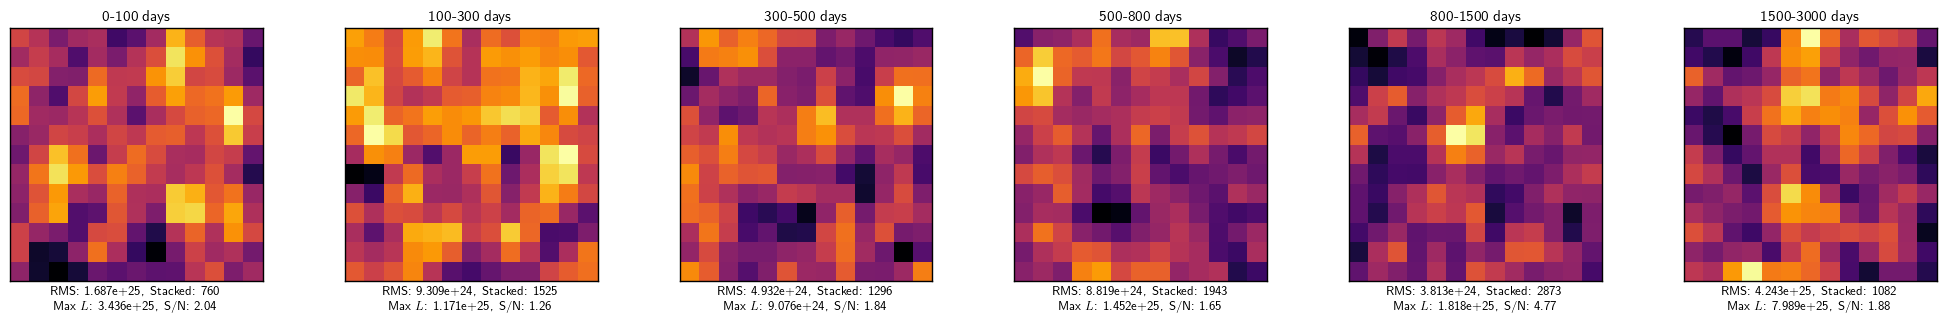

(<Figure size 2520x320 with 6 Axes>,
 array([<Axes: title={'center': '0-100 days'}, xlabel='RMS: 1.687e+25, Stacked: 760\nMax $L$: 3.436e+25, S/N: 2.04'>,
        <Axes: title={'center': '100-300 days'}, xlabel='RMS: 9.309e+24, Stacked: 1525\nMax $L$: 1.171e+25, S/N: 1.26'>,
        <Axes: title={'center': '300-500 days'}, xlabel='RMS: 4.932e+24, Stacked: 1296\nMax $L$: 9.076e+24, S/N: 1.84'>,
        <Axes: title={'center': '500-800 days'}, xlabel='RMS: 8.819e+24, Stacked: 1943\nMax $L$: 1.452e+25, S/N: 1.65'>,
        <Axes: title={'center': '800-1500 days'}, xlabel='RMS: 3.813e+24, Stacked: 2873\nMax $L$: 1.818e+25, S/N: 4.77'>,
        <Axes: title={'center': '1500-3000 days'}, xlabel='RMS: 4.243e+25, Stacked: 1082\nMax $L$: 7.989e+25, S/N: 1.88'>],
       dtype=object))

In [ ]:
plot_stacks_for_type(stacked_df, which_type = 'Ia')

#### II

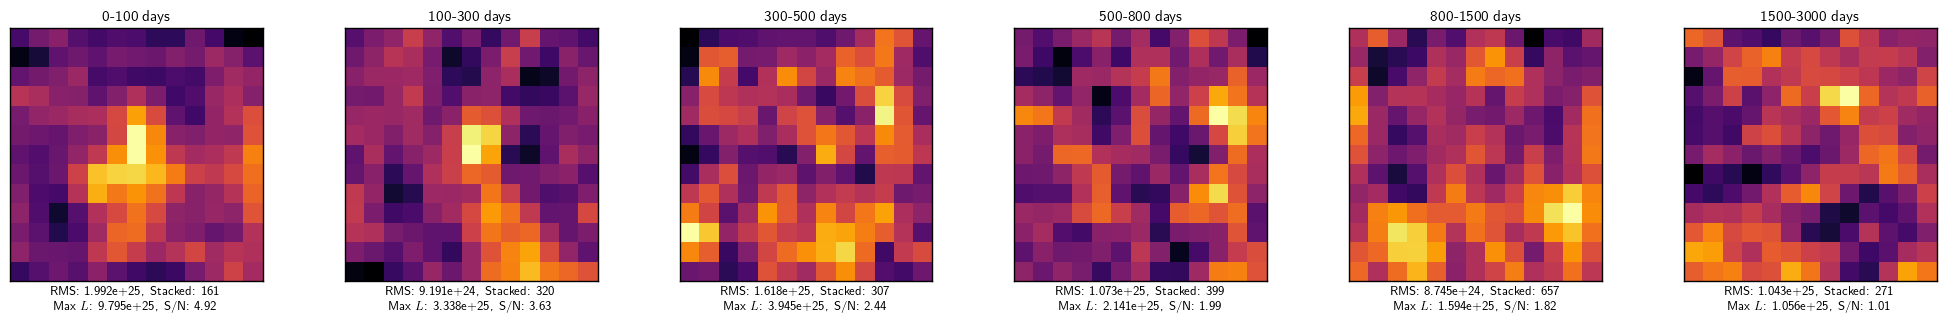

(<Figure size 2520x320 with 6 Axes>,
 array([<Axes: title={'center': '0-100 days'}, xlabel='RMS: 1.992e+25, Stacked: 161\nMax $L$: 9.795e+25, S/N: 4.92'>,
        <Axes: title={'center': '100-300 days'}, xlabel='RMS: 9.191e+24, Stacked: 320\nMax $L$: 3.338e+25, S/N: 3.63'>,
        <Axes: title={'center': '300-500 days'}, xlabel='RMS: 1.618e+25, Stacked: 307\nMax $L$: 3.945e+25, S/N: 2.44'>,
        <Axes: title={'center': '500-800 days'}, xlabel='RMS: 1.073e+25, Stacked: 399\nMax $L$: 2.141e+25, S/N: 1.99'>,
        <Axes: title={'center': '800-1500 days'}, xlabel='RMS: 8.745e+24, Stacked: 657\nMax $L$: 1.594e+25, S/N: 1.82'>,
        <Axes: title={'center': '1500-3000 days'}, xlabel='RMS: 1.043e+25, Stacked: 271\nMax $L$: 1.056e+25, S/N: 1.01'>],
       dtype=object))

In [ ]:
plot_stacks_for_type(stacked_df, which_type = 'II')

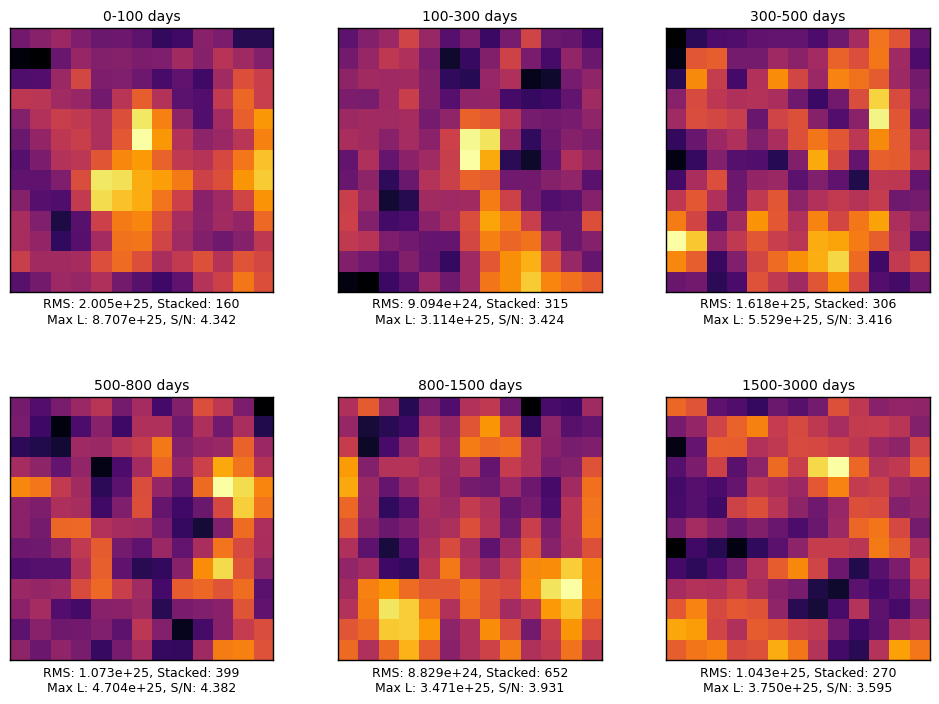

In [ ]:
plot_stacked_arrays_individual_scaling(filtered_stacked_ii_df, 'ii_stacking')

C:\Users\Jack Pope\AppData\Local\Temp\ipykernel_21444\955971619.py:76: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])  # Ensure space for the color bar


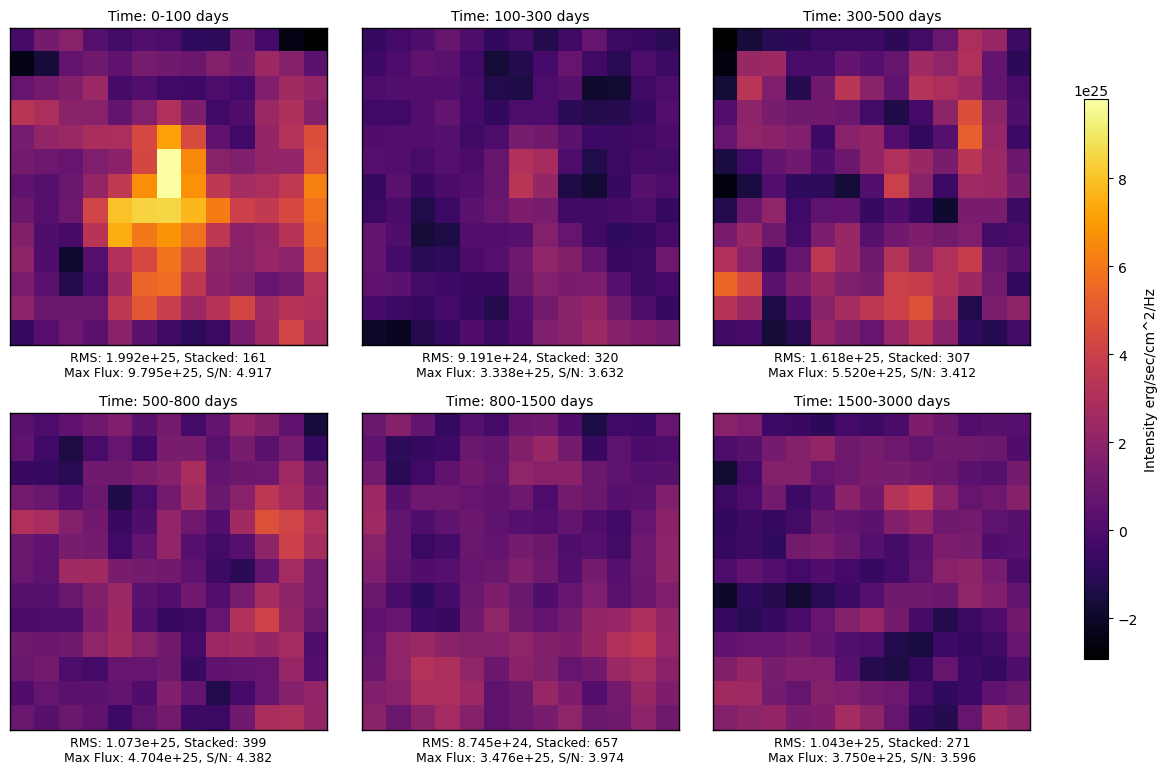

In [ ]:
plot_stacked_arrays(stacked_ii_df)

C:\Users\Jack Pope\AppData\Local\Temp\ipykernel_21444\955971619.py:76: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])  # Ensure space for the color bar


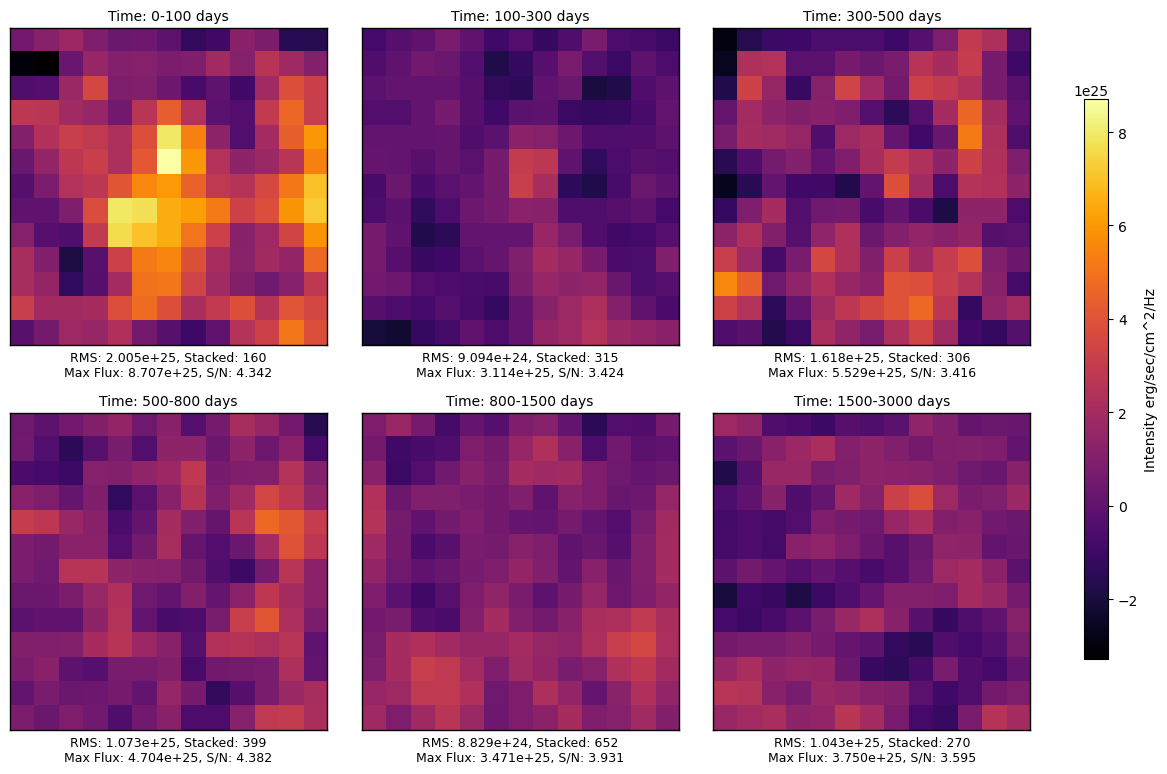

In [ ]:
plot_stacked_arrays(filtered_stacked_ii_df)

#### IIn

C:\Users\Jack Pope\AppData\Local\Temp\ipykernel_21444\955971619.py:76: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])  # Ensure space for the color bar


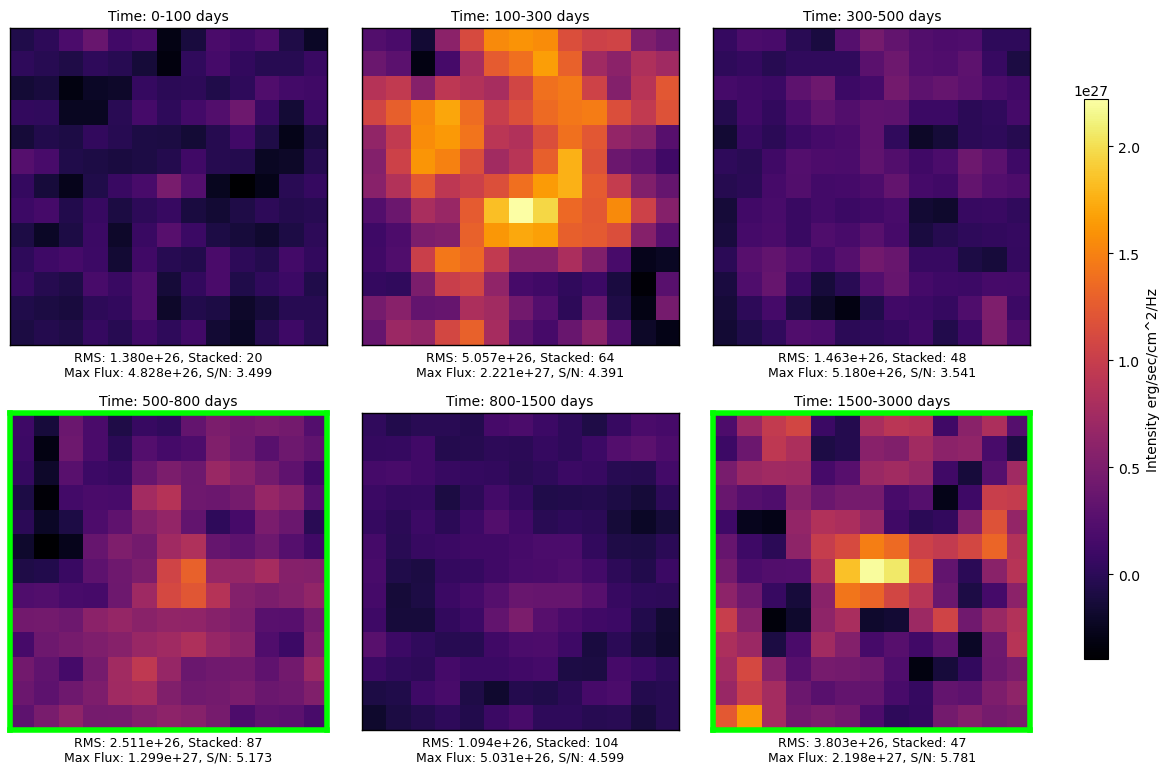

In [ ]:
plot_stacked_arrays(stacked_iin_df)

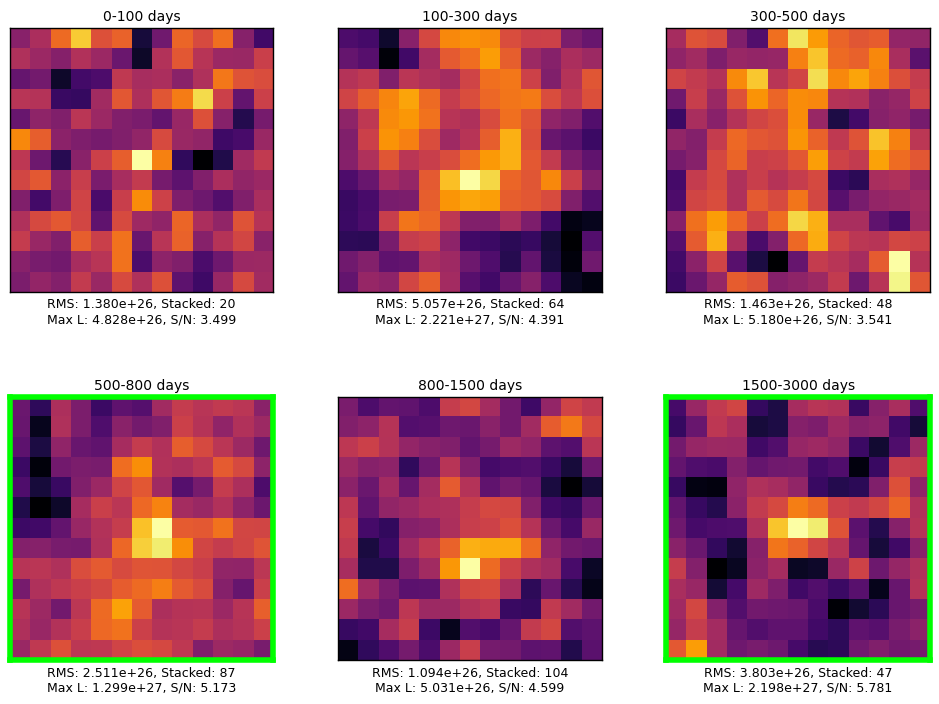

In [ ]:
plot_stacked_arrays_individual_scaling(stacked_iin_df, 'iin_stacking')

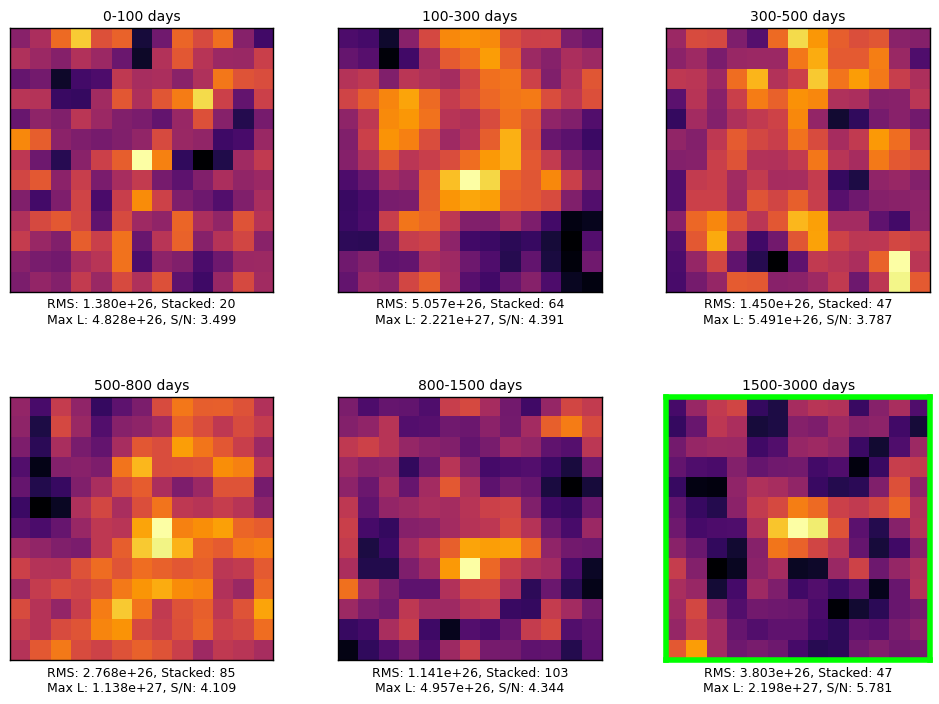

In [ ]:
plot_stacked_arrays_individual_scaling(filtered_stacked_iin_df, 'iin_stacking')

#### stripped envelope

C:\Users\Jack Pope\AppData\Local\Temp\ipykernel_21444\955971619.py:76: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])  # Ensure space for the color bar


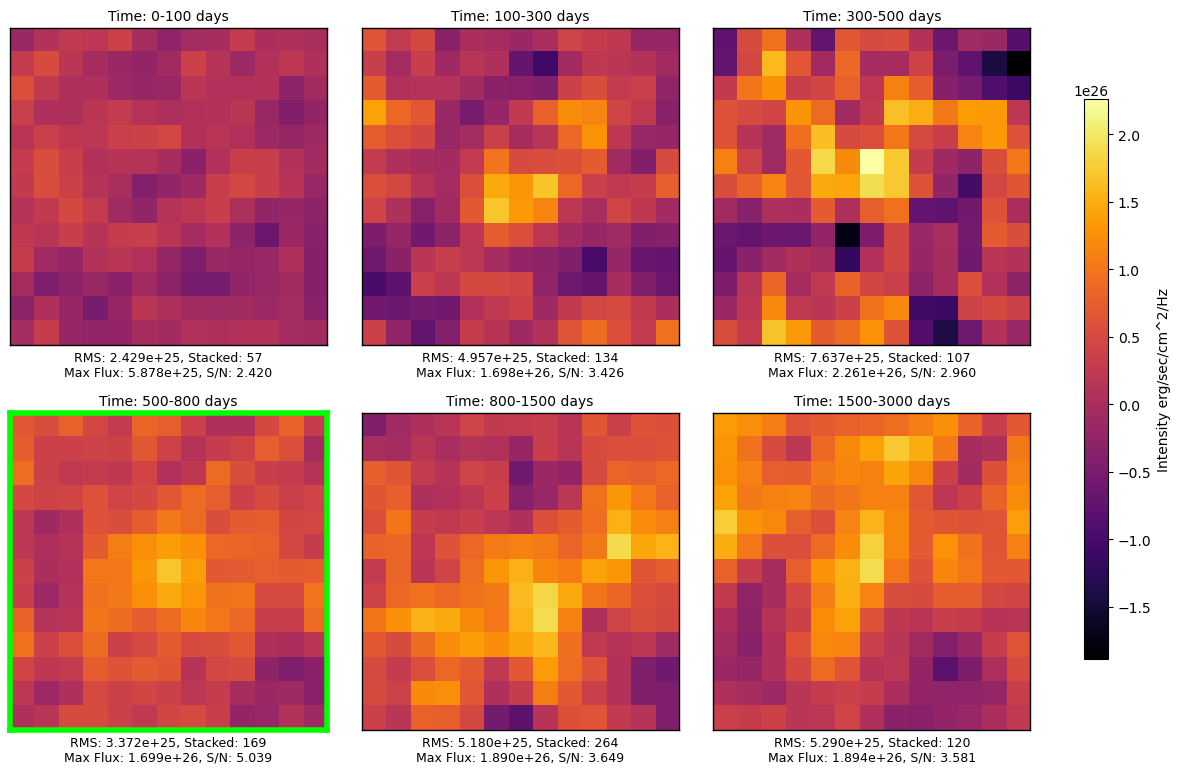

In [ ]:
plot_stacked_arrays(stacked_stripped_envelope_df)

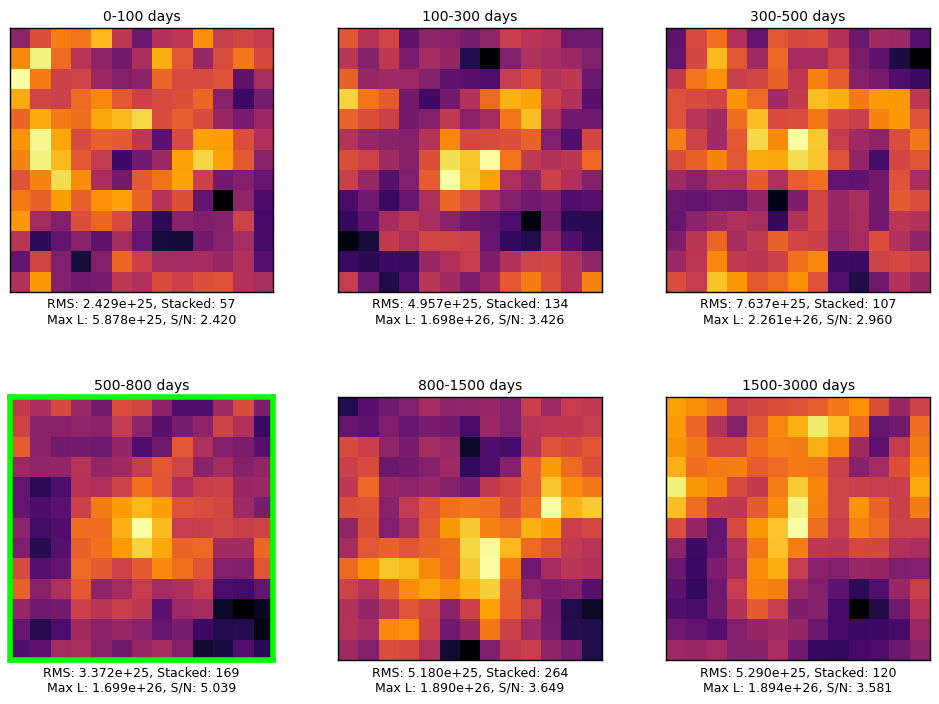

In [ ]:
plot_stacked_arrays_individual_scaling(stacked_stripped_envelope_df, 'stripped_envelope_stacking')

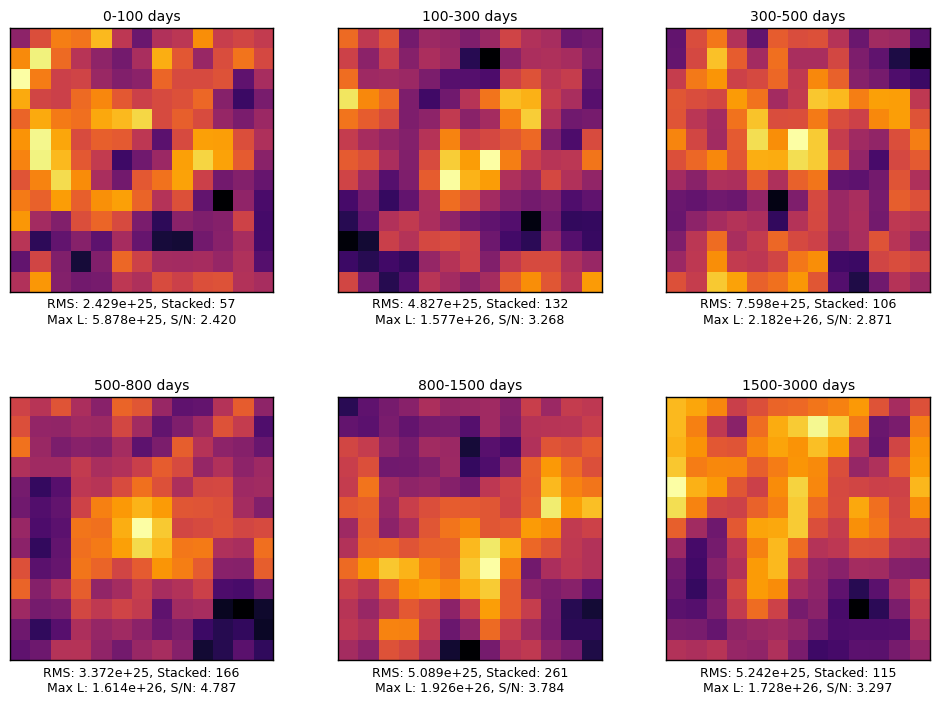

In [ ]:
plot_stacked_arrays_individual_scaling(filtered_stacked_stripped_envelope_df, 'stripped_envelope_stacking')


#### TDE

C:\Users\Jack Pope\AppData\Local\Temp\ipykernel_21444\955971619.py:76: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])  # Ensure space for the color bar


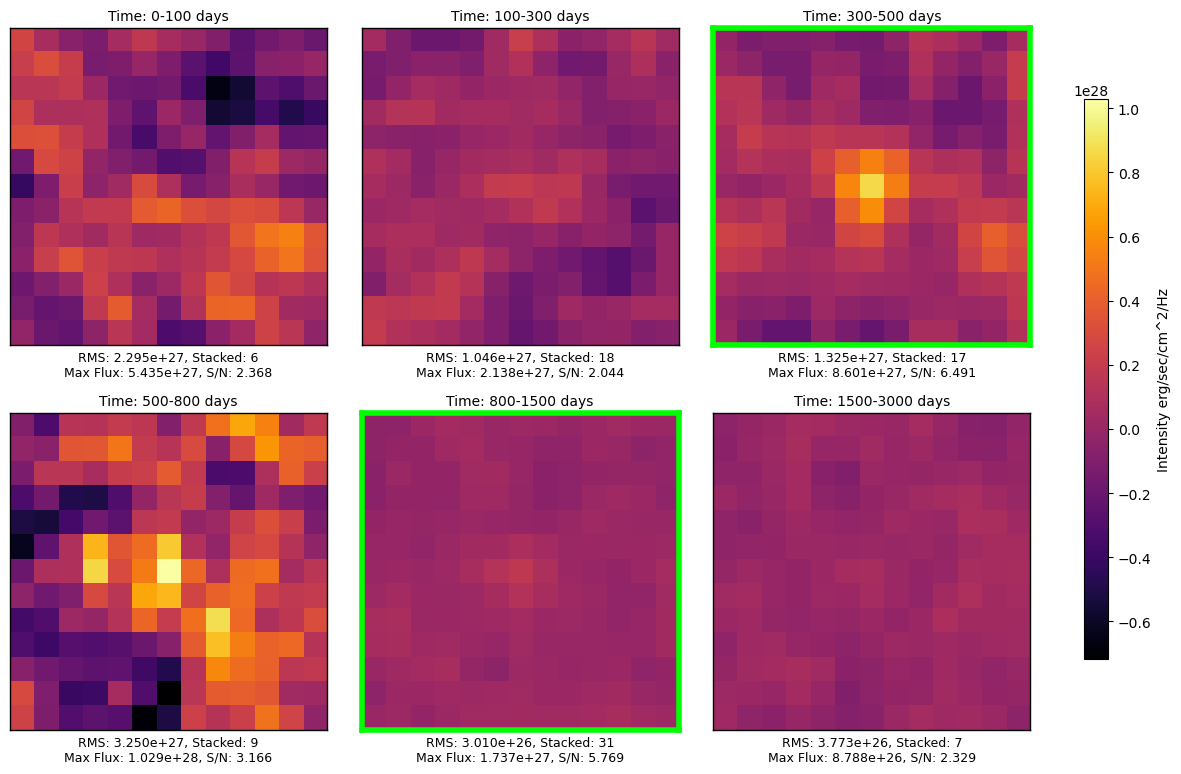

In [ ]:
plot_stacked_arrays(stacked_tde_df)

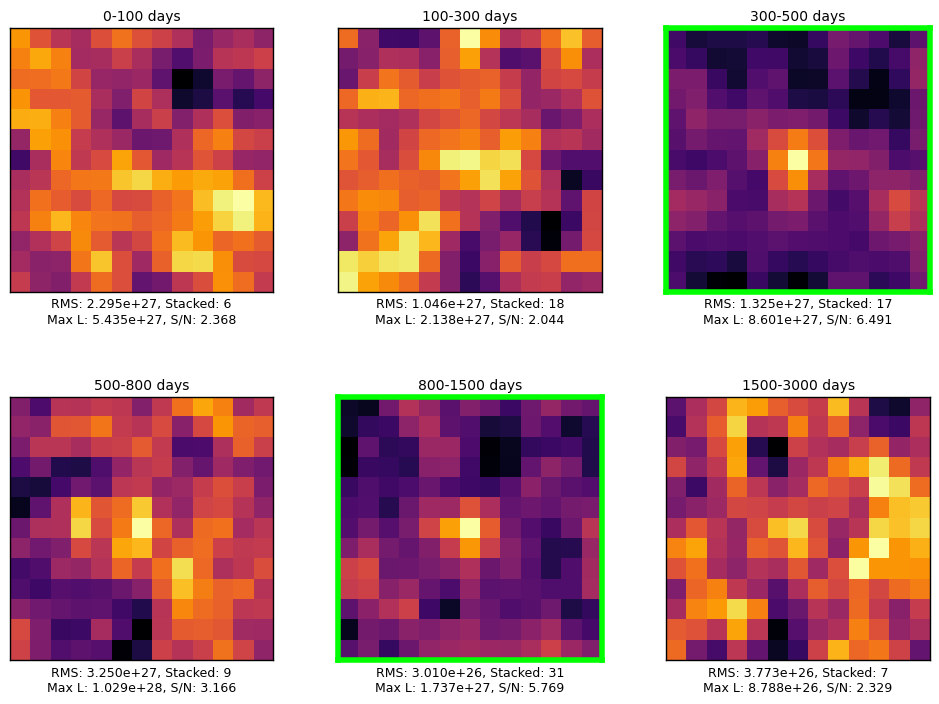

In [ ]:
plot_stacked_arrays_individual_scaling(stacked_tde_df, 'tde_stacking')

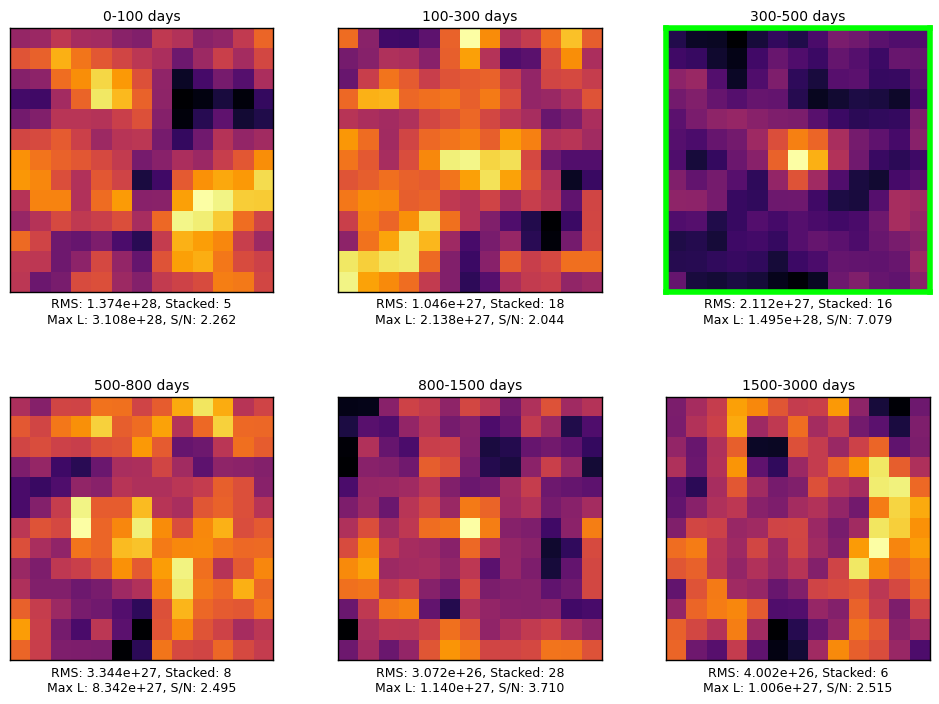

In [ ]:
plot_stacked_arrays_individual_scaling(filtered_stacked_tde_df, 'tde_stacking')

C:\Users\Jack Pope\AppData\Local\Temp\ipykernel_21444\955971619.py:76: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])  # Ensure space for the color bar


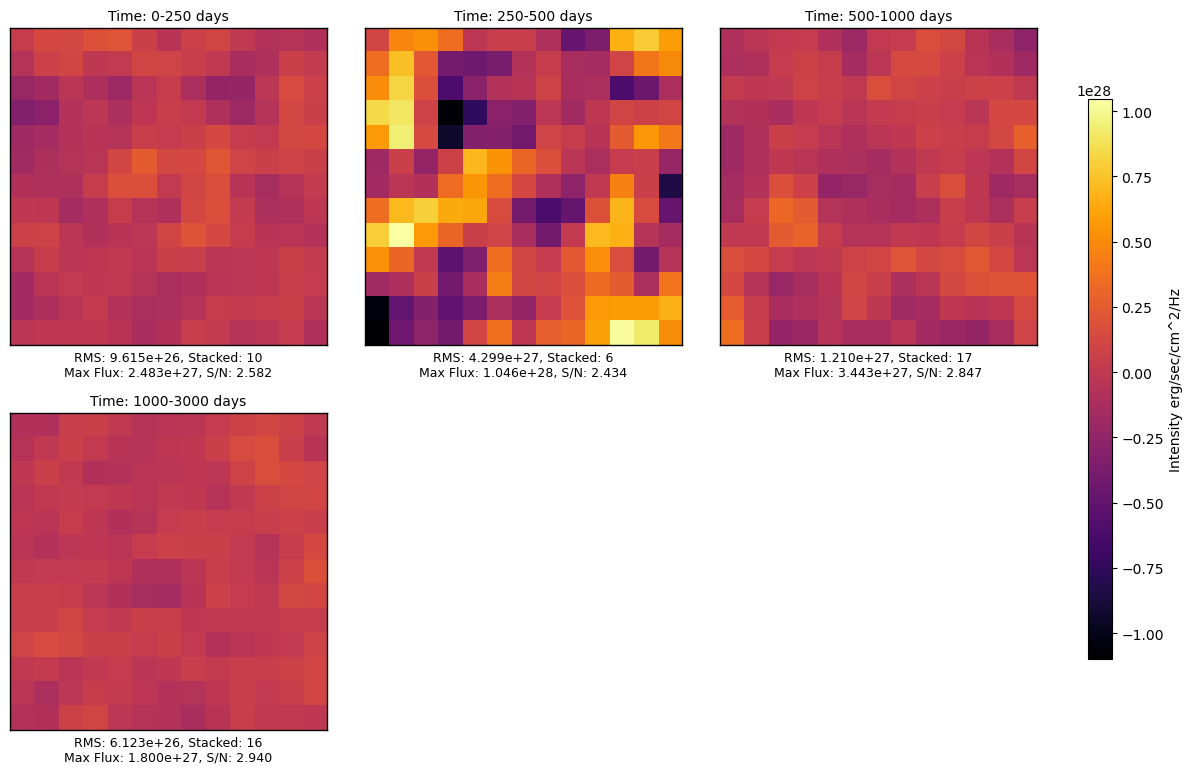

In [ ]:
plot_stacked_arrays(stacked_ibn_icn_df)

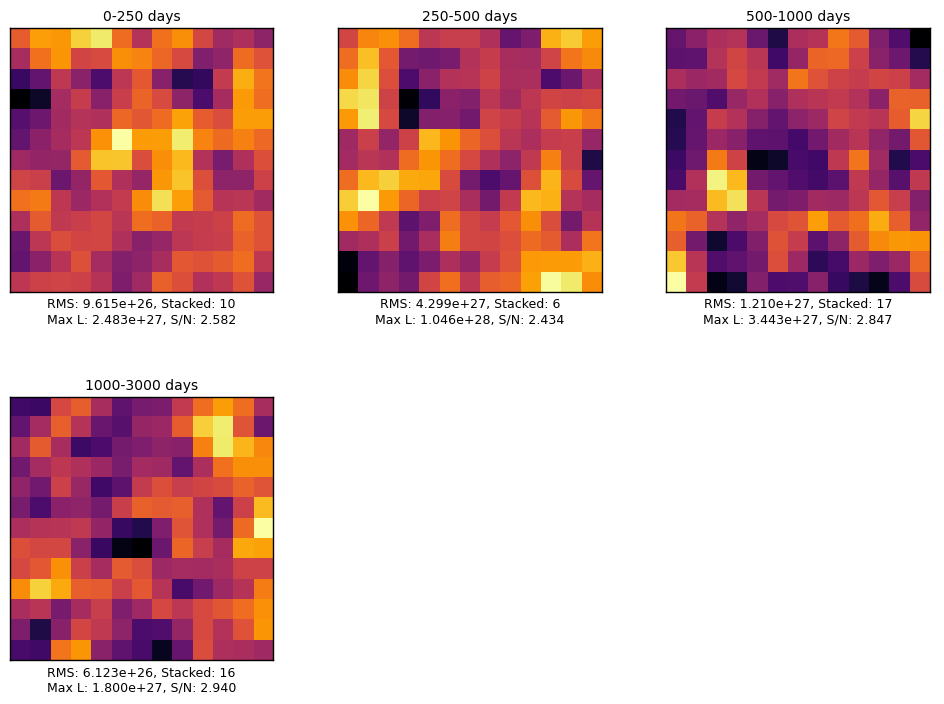

In [ ]:
plot_stacked_arrays_individual_scaling(stacked_ibn_icn_df, 'ibn_icn_stacking')

C:\Users\Jack Pope\AppData\Local\Temp\ipykernel_21444\955971619.py:76: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])  # Ensure space for the color bar


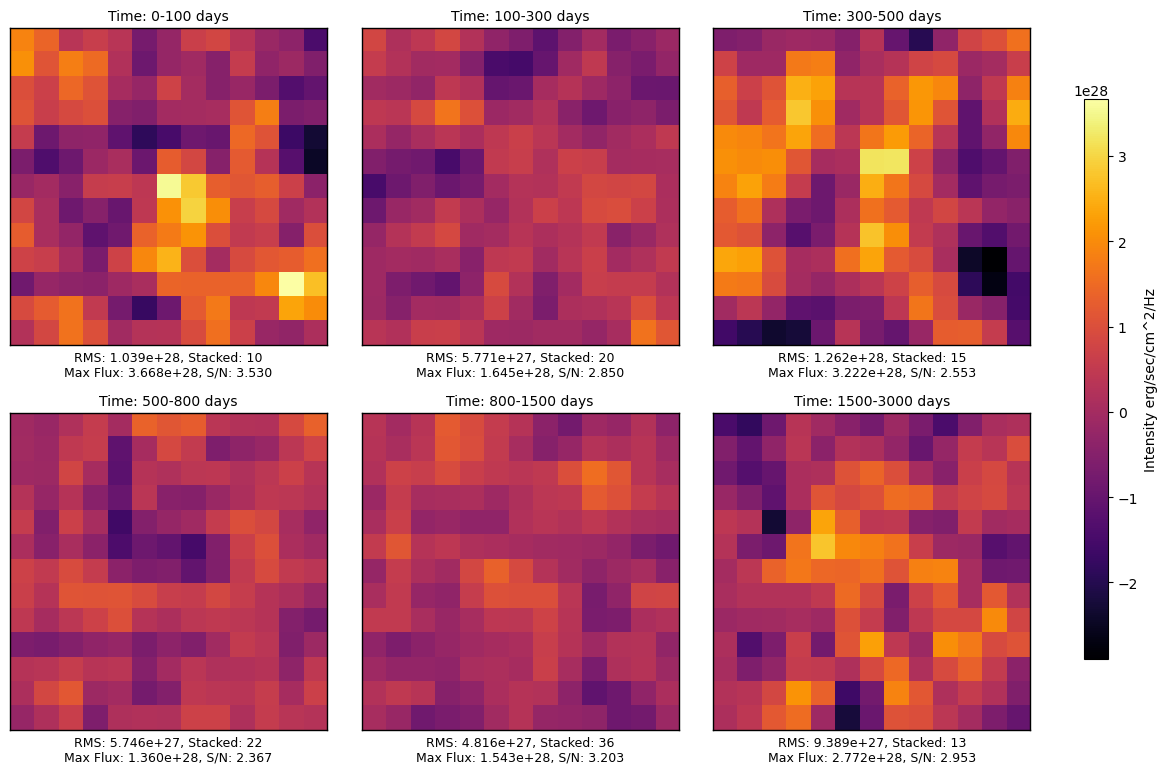

In [ ]:
plot_stacked_arrays(stacked_slsn1_df)

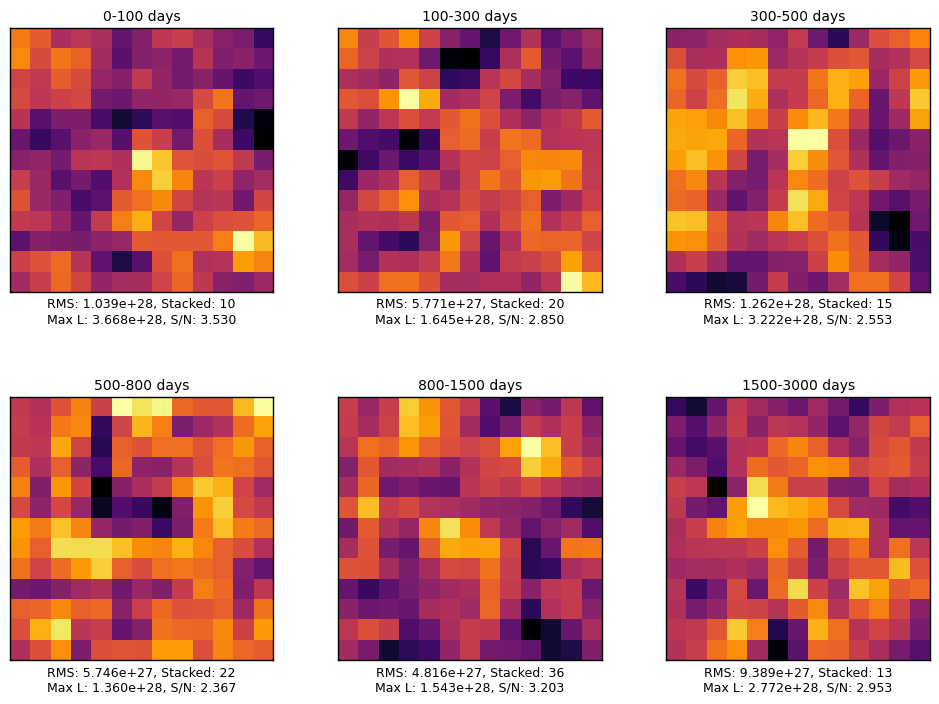

In [ ]:
plot_stacked_arrays_individual_scaling(stacked_slsn1_df, 'slsn1_stacking')

C:\Users\Jack Pope\AppData\Local\Temp\ipykernel_21444\955971619.py:76: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])  # Ensure space for the color bar


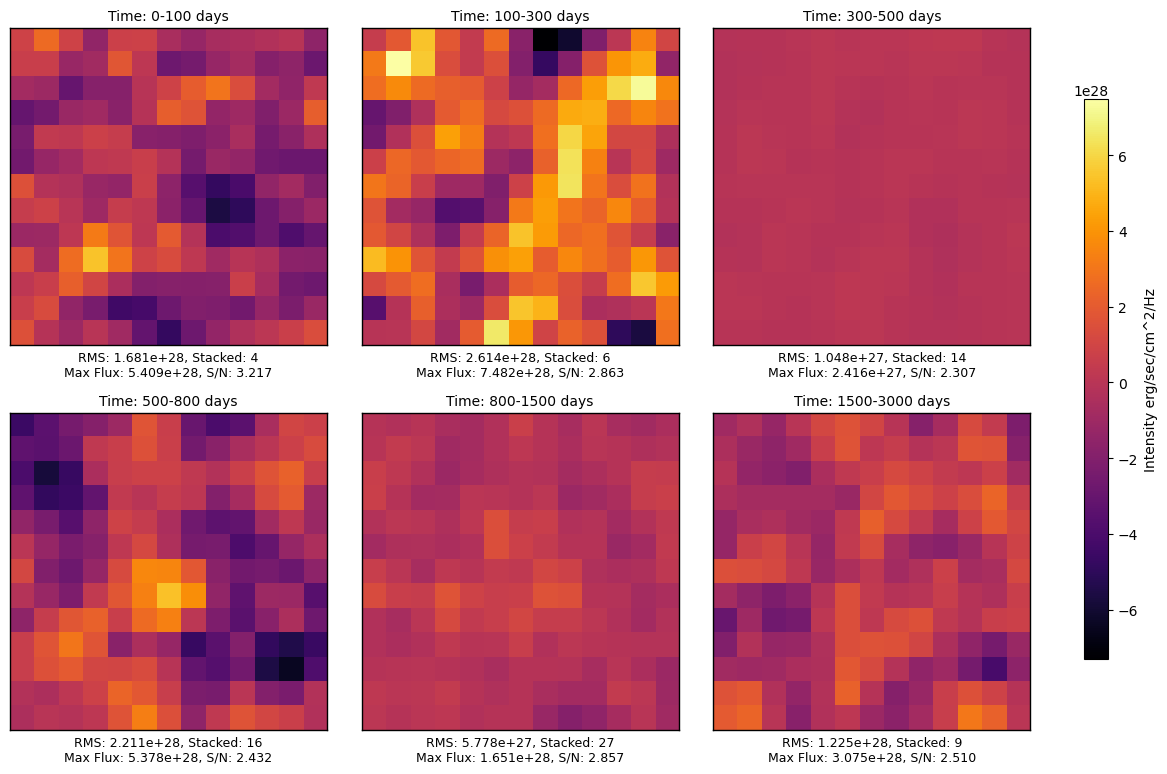

In [ ]:
plot_stacked_arrays(stacked_slsn2_df)

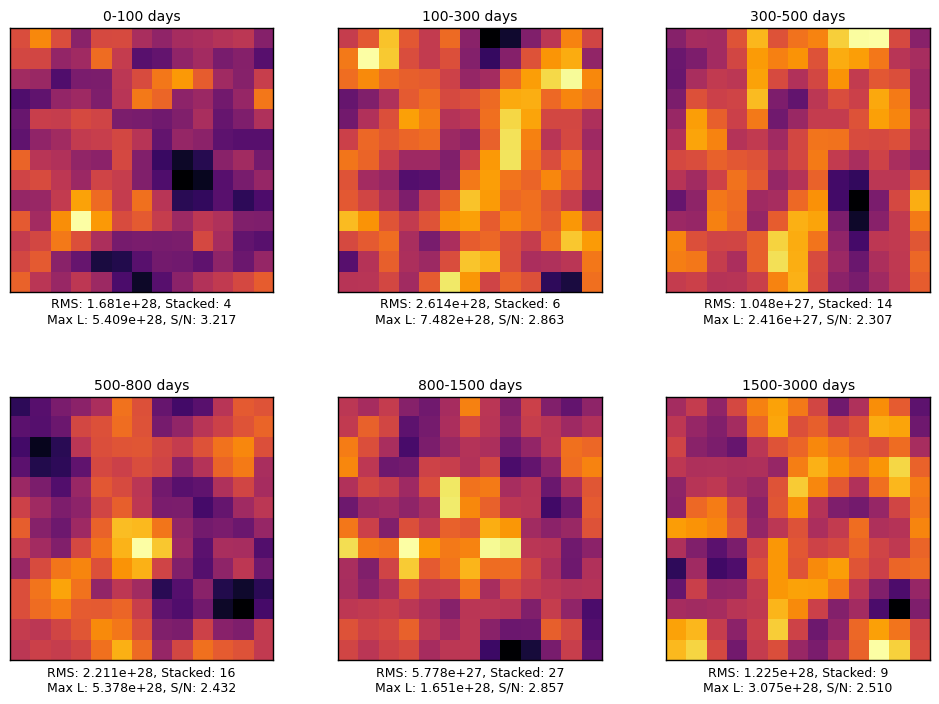

In [ ]:
plot_stacked_arrays_individual_scaling(stacked_slsn2_df, 'slsn2_stacking')

In [ ]:
tde16 = filtered_tde_df[(filtered_tde_df['Rest_DeltaT'] > 300) & (filtered_tde_df['Rest_DeltaT'] < 500)]

In [ ]:
def plot_npy_arrays(df, title="TDE Cutouts", file_col="File Path", name_col="Name", 
                    cmap="inferno", unit="erg s$^{-1}$ Hz$^{-1}$"):
    """
    Visualize .npy arrays stored in the file path column of a DataFrame.
    Uses a fixed 4x4 grid (16 arrays). Each subplot is scaled individually.
    Recalculates RMS from each file. Labels each subplot with Name, RMS, Max L, and S/N.
    """
    plt.style.use('default')
    num_arrays = len(df)
    ncols, nrows = 4, 4
    
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(14, 14))
    axes = axes.flatten()
    
    for i, ax in enumerate(axes):
        if i < num_arrays:
            file_path = df.iloc[i][file_col]
            arr = np.load(file_path)  # load .npy array
            
            vmin, vmax = np.min(arr), np.max(arr)
            im = ax.imshow(arr, cmap=cmap, interpolation="nearest", vmin=vmin, vmax=vmax)
            
            # Recalculate RMS
            rms = process_file_for_rms(file_path)
            maxL = np.max(arr)
            snr = maxL / rms if rms != 0 else np.nan
            
            # Title = transient name
            name = df.iloc[i][name_col]
            ax.set_title(f"{name}", fontsize=9)
            
            # Info below
            ax.set_xlabel(
                f"RMS: {rms:.2e}\nMax L: {maxL:.2e}\nS/N: {snr:.2f}",
                fontsize=8, color="black"
            )
            
            ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
            
            # Lime outline for high S/N
            if snr >= 5:
                for spine in ax.spines.values():
                    spine.set_edgecolor('lime')
                    spine.set_linewidth(3)
            else:
                for spine in ax.spines.values():
                    spine.set_edgecolor('black')
                    spine.set_linewidth(1)
        else:
            ax.axis("off")
    
    fig.suptitle(title, fontsize=16, y=0.92)
    plt.subplots_adjust(wspace=0.4, hspace=0.6)
    plt.show()

In [ ]:
tde16

,Name,Epoch,RA,Dec,type,redshift,Distance_Mpc,Rest_DeltaT,RMS,File Path
32,ZTF18aabdajx,3,12:20:45.07,+49:33:04.6,TDE,0.0284,121.714286,336.814469,2.403191e+27,final_luminosity_arrays\ZTF18aabdajx_epoch_3_l...
45,ZTF18aabtxvd,1,07:56:54.54,+34:15:43.6,TDE,0.0710,304.285714,428.267974,1.517003e+28,final_luminosity_arrays\ZTF18aabtxvd_epoch_1_l...
171,ZTF18aahqkbt,1,08:15:26.62,+45:35:31.9,TDE,0.0510,218.571429,389.902958,8.698767e+27,final_luminosity_arrays\ZTF18aahqkbt_epoch_1_l...
4228,ZTF19aapreis,2,20:57:02.96,+14:12:16.2,TDE,0.0512,219.428571,440.958041,1.045284e+28,final_luminosity_arrays\ZTF19aapreis_epoch_2_l...
4348,ZTF19aarioci,2,14:09:41.88,+55:29:28.0,TDE,0.0740,317.142857,456.904108,1.356998e+28,final_luminosity_arrays\ZTF19aarioci_epoch_2_l...
5569,ZTF19abidbya,2,23:11:12.30,-01:00:10.7,TDE,0.1170,501.428571,338.032231,5.252152e+28,final_luminosity_arrays\ZTF19abidbya_epoch_2_l...
10247,ZTF20abgwfek,2,15:21:20.08,+14:04:10.5,TDE,0.0620,265.714286,483.752618,9.503038e+27,final_luminosity_arrays\ZTF20abgwfek_epoch_2_l...
10304,ZTF20abisysx,2,16:58:12.98,+02:07:03.0,TDE,0.0840,360.000000,448.124947,2.507680e+28,final_luminosity_arrays\ZTF20abisysx_epoch_2_l...
11287,ZTF20acaazkt,2,10:08:53.45,+42:43:00.3,TDE,0.0440,188.571429,353.935230,6.380513e+27,final_luminosity_arrays\ZTF20acaazkt_epoch_2_l...
11973,ZTF20acnznms,2,11:00:00.33,+21:06:45.8,TDE,0.2040,874.285714,313.540399,8.775644e+28,final_luminosity_arrays\ZTF20acnznms_epoch_2_l...


In [ ]:
filtered_tde_df

,Name,Epoch,RA,Dec,type,redshift,Distance_Mpc,Rest_DeltaT,RMS,File Path
30,ZTF18aabdajx,1,12:20:45.07,+49:33:04.6,TDE,0.0284,121.714286,-1512.660443,1.799801e+27,final_luminosity_arrays\ZTF18aabdajx_epoch_1_l...
31,ZTF18aabdajx,2,12:20:45.07,+49:33:04.6,TDE,0.0284,121.714286,-554.861921,2.722361e+27,final_luminosity_arrays\ZTF18aabdajx_epoch_2_l...
32,ZTF18aabdajx,3,12:20:45.07,+49:33:04.6,TDE,0.0284,121.714286,336.814469,2.403191e+27,final_luminosity_arrays\ZTF18aabdajx_epoch_3_l...
39,ZTF18aabkvpi,1,11:40:09.40,+15:19:38.5,TDE,0.0110,47.142857,-80.744965,3.352943e+26,final_luminosity_arrays\ZTF18aabkvpi_epoch_1_l...
40,ZTF18aabkvpi,2,11:40:09.40,+15:19:38.5,TDE,0.0110,47.142857,986.515173,3.238284e+26,final_luminosity_arrays\ZTF18aabkvpi_epoch_2_l...
...,...,...,...,...,...,...,...,...,...,...
27176,ZTF24aajvvhj,2,10:31:38.90,+34:54:30.0,TDE,0.1200,514.285714,-768.143415,3.616254e+28,final_luminosity_arrays\ZTF24aajvvhj_epoch_2_l...
27177,ZTF24aajvvhj,3,10:31:38.90,+34:54:30.0,TDE,0.1200,514.285714,80.963728,4.178310e+28,final_luminosity_arrays\ZTF24aajvvhj_epoch_3_l...
27901,ZTF24aatxshz,1,18:14:06.19,+36:14:59.7,TDE,0.1398,599.142857,-2125.263367,5.354528e+28,final_luminosity_arrays\ZTF24aatxshz_epoch_1_l...
27902,ZTF24aatxshz,2,18:14:06.19,+36:14:59.7,TDE,0.1398,599.142857,-1197.907690,5.665459e+28,final_luminosity_arrays\ZTF24aatxshz_epoch_2_l...


In [ ]:
file_path = filtered_tde_df.iloc[0]["File Path"]  # pick the first row (or any row)
rms_value = process_array_for_rms(np.load(file_path))
print(rms_value)

1.9280592021147893e+27


In [ ]:
np.load(filtered_tde_df.iloc[0]['File Path'])

array([[-3.04322690e+27, -8.94620049e+26,  4.59592663e+26,
         1.12385165e+27, -7.38938285e+26, -1.11444738e+27,
        -2.56336516e+27, -3.57852766e+27, -3.02164600e+27,
        -2.47704259e+27, -2.29874468e+27, -1.06628346e+27,
         2.62802441e+26],
       [-6.28292907e+27, -3.81498819e+27, -8.79746907e+26,
        -5.31601980e+26, -1.57525926e+27, -1.05202918e+27,
        -8.31155062e+26, -2.11437678e+27,  6.22071948e+26,
         2.70104276e+27,  2.29814984e+26,  1.66002825e+27,
         2.29114909e+27],
       [-2.68622095e+27, -1.49173446e+27,  5.12041534e+26,
        -1.37774474e+27, -1.15182420e+27,  1.64375204e+27,
         1.98971165e+27, -1.12298058e+27, -6.33443797e+26,
         2.19921708e+27,  8.60702859e+26,  2.52964278e+26,
        -1.25196528e+26],
       [ 3.49998395e+26,  7.06217491e+26,  1.51776458e+27,
         7.97511161e+26,  7.80469380e+26,  3.97619750e+27,
         4.99305957e+27,  1.64638252e+27, -3.13602585e+26,
        -8.43668816e+26, -1.86470273e

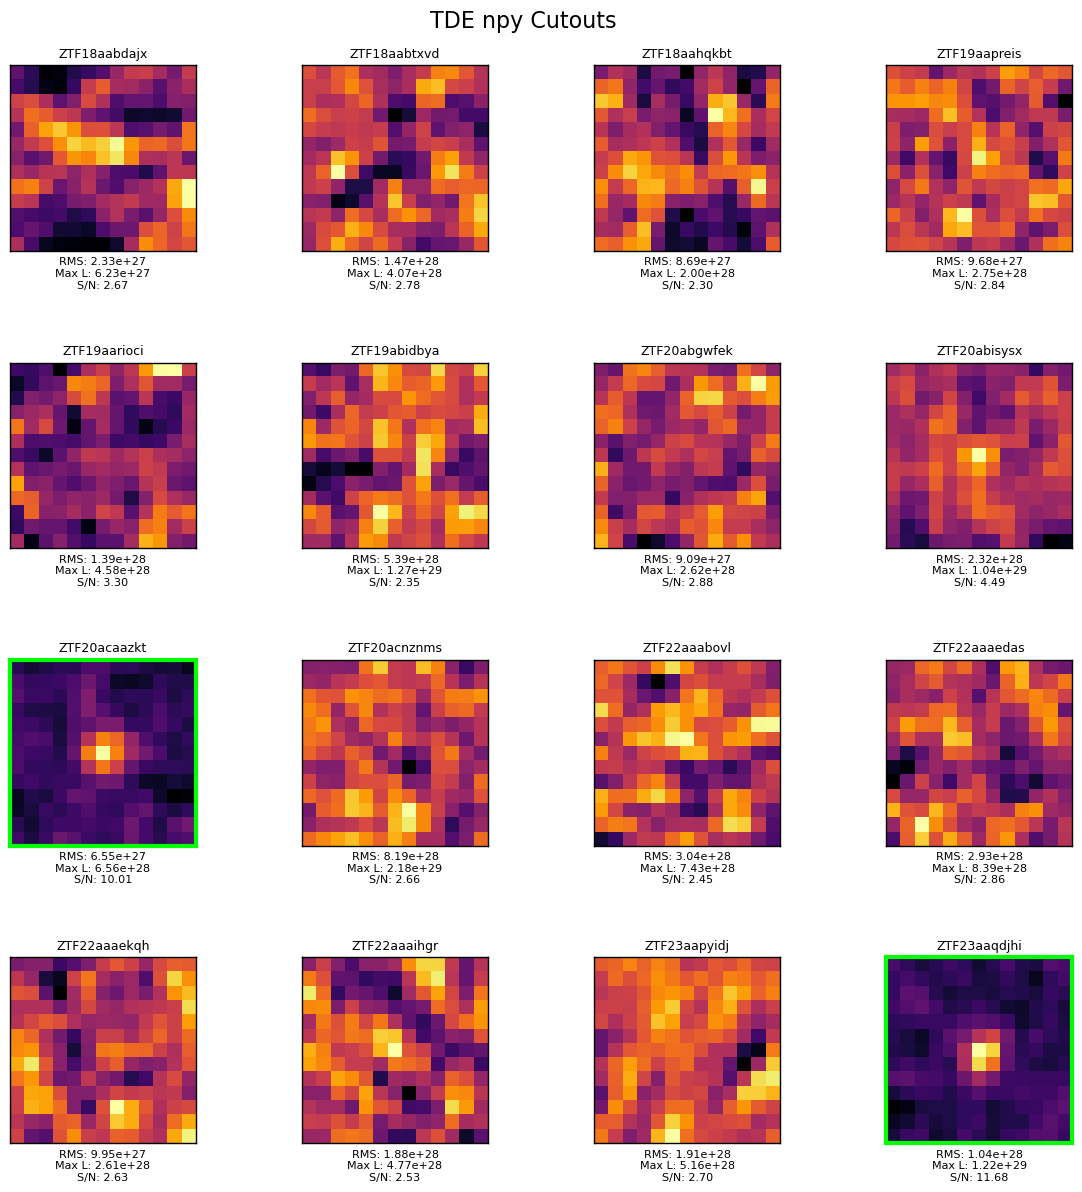

In [ ]:
plot_npy_arrays(tde16, title="TDE npy Cutouts")